<a href="https://colab.research.google.com/github/hannaginther/ENGG680_2025_Fall/blob/main/Project/Model_Code/TEST4_TwoStage_pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

In [ ]:
!pip install catboost
!pip install lightgbm
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 7.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')

##**Stage 1: CatBoost Models (Classification + Regression per Class)**
- Run this first on GPU, then switch to CPU for LGBM

In [ ]:
# @title
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("="*70)
print("STAGE 1: CATBOOST MODELS (GPU)")
print("="*70)

# ==================== DATA PREPARATION ====================
print("\nLoading and preparing data...")

# Load your data
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("\nApplying feature engineering...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# ==================== CREATE TARGET VARIABLES ====================
print("\nCreating target variables...")

# Binary classification target: Short (<=3 days) vs Long (>3 days)
native_df['los_class'] = (native_df['length_of_stay'] > 3).astype(int)

print(f"Class distribution:")
print(f"  Short stay (<=3 days): {(native_df['los_class'] == 0).sum():,} ({(native_df['los_class'] == 0).mean()*100:.1f}%)")
print(f"  Long stay (>3 days): {(native_df['los_class'] == 1).sum():,} ({(native_df['los_class'] == 1).mean()*100:.1f}%)")

# ==================== PREPARE FEATURES ====================
# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare X and y
X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_class = native_df['los_class']
y_reg = native_df['length_of_stay']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update categorical feature names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

# Get categorical feature indices
cat_features_indices = [X.columns.get_loc(col) for col in cat_features_cleaned
                        if col in X.columns]

print(f"\nDataset info:")
print(f"  Total samples: {len(X):,}")
print(f"  Total features: {X.shape[1]}")
print(f"  Categorical features: {len(cat_features_indices)}")

# ==================== TRAIN-TEST SPLIT ====================
print("\nSplitting data...")
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

STAGE 1: CATBOOST MODELS (GPU)

Loading and preparing data...

Applying feature engineering...
✓ Created 8 new engineered features

Creating target variables...
Class distribution:
  Short stay (<=3 days): 1,346,383 (51.8%)
  Long stay (>3 days): 1,251,320 (48.2%)

Dataset info:
  Total samples: 2,597,703
  Total features: 25
  Categorical features: 17

Splitting data...
Train set: 2,078,162 samples
Test set: 519,541 samples


In [ ]:
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("="*70)
print("STAGE 1: CATBOOST MODELS (GPU)")
print("="*70)

# ==================== DATA PREPARATION ====================
print("\nLoading and preparing data...")

# Load your data
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("\nApplying feature engineering...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# ==================== ANALYZE LOS DISTRIBUTION ====================
print("\n" + "="*70)
print("ANALYZING LENGTH OF STAY DISTRIBUTION")
print("="*70)

los_stats = native_df['length_of_stay'].describe()
print("\nDescriptive Statistics:")
print(f"  Mean: {los_stats['mean']:.2f} days")
print(f"  Median: {native_df['length_of_stay'].median():.2f} days")
print(f"  Std Dev: {los_stats['std']:.2f} days")
print(f"  Min: {los_stats['min']:.0f} days")
print(f"  Max: {los_stats['max']:.0f} days")
print(f"  25th percentile: {los_stats['25%']:.2f} days")
print(f"  75th percentile: {los_stats['75%']:.2f} days")
print(f"  90th percentile: {native_df['length_of_stay'].quantile(0.90):.2f} days")
print(f"  95th percentile: {native_df['length_of_stay'].quantile(0.95):.2f} days")
print(f"  99th percentile: {native_df['length_of_stay'].quantile(0.99):.2f} days")

# Calculate skewness
from scipy.stats import skew
skewness = skew(native_df['length_of_stay'])
print(f"\nSkewness: {skewness:.2f} (highly right-skewed)")


STAGE 1: CATBOOST MODELS (GPU)

Loading and preparing data...

Applying feature engineering...
✓ Created 8 new engineered features

ANALYZING LENGTH OF STAY DISTRIBUTION

Descriptive Statistics:
  Mean: 6.23 days
  Median: 3.00 days
  Std Dev: 9.25 days
  Min: 1 days
  Max: 120 days
  25th percentile: 2.00 days
  75th percentile: 7.00 days
  90th percentile: 14.00 days
  95th percentile: 20.00 days
  99th percentile: 44.00 days

Skewness: 5.70 (highly right-skewed)


In [ ]:
import pandas as pd
import numpy as np
import joblib
from catboost import CatBoostClassifier, CatBoostRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
from optuna.visualization import plot_optimization_history, plot_param_importances
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("="*70)
print("STAGE 1: CATBOOST MODELS (GPU)")
print("="*70)

# ==================== DATA PREPARATION ====================
print("\nLoading and preparing data...")

# Load your data
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("\nApplying feature engineering...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# ==================== ANALYZE LOS DISTRIBUTION ====================
print("\n" + "="*70)
print("ANALYZING LENGTH OF STAY DISTRIBUTION")
print("="*70)

los_stats = native_df['length_of_stay'].describe()
print("\nDescriptive Statistics:")
print(f"  Mean: {los_stats['mean']:.2f} days")
print(f"  Median: {native_df['length_of_stay'].median():.2f} days")
print(f"  Std Dev: {los_stats['std']:.2f} days")
print(f"  Min: {los_stats['min']:.0f} days")
print(f"  Max: {los_stats['max']:.0f} days")
print(f"  25th percentile: {los_stats['25%']:.2f} days")
print(f"  75th percentile: {los_stats['75%']:.2f} days")
print(f"  90th percentile: {native_df['length_of_stay'].quantile(0.90):.2f} days")
print(f"  95th percentile: {native_df['length_of_stay'].quantile(0.95):.2f} days")
print(f"  99th percentile: {native_df['length_of_stay'].quantile(0.99):.2f} days")

# Calculate skewness
from scipy.stats import skew
skewness = skew(native_df['length_of_stay'])
print(f"\nSkewness: {skewness:.2f} (highly right-skewed)")

# ==================== CREATE TARGET VARIABLES ====================
print("\n" + "="*70)
print("DETERMINING OPTIMAL CLASSIFICATION THRESHOLD")
print("="*70)

# Option 1: Use median for balanced classes
median_los = native_df['length_of_stay'].median()

# Option 2: Use a clinically meaningful threshold (e.g., 75th percentile)
percentile_75 = native_df['length_of_stay'].quantile(0.75)

# Option 3: Use natural break in distribution
# Find the "elbow" where distribution changes significantly
print("\nEvaluating different threshold options:")
print(f"\n1. Median-based (balanced classes): {median_los:.1f} days")
median_split = native_df['length_of_stay'] > median_los
print(f"   Class 0 (≤{median_los:.1f}d): {(~median_split).sum():,} ({(~median_split).mean()*100:.1f}%)")
print(f"   Class 1 (>{median_los:.1f}d): {median_split.sum():,} ({median_split.mean()*100:.1f}%)")

print(f"\n2. 75th percentile (top quartile): {percentile_75:.1f} days")
perc75_split = native_df['length_of_stay'] > percentile_75
print(f"   Class 0 (≤{percentile_75:.1f}d): {(~perc75_split).sum():,} ({(~perc75_split).mean()*100:.1f}%)")
print(f"   Class 1 (>{percentile_75:.1f}d): {perc75_split.sum():,} ({perc75_split.mean()*100:.1f}%)")

print(f"\n3. Traditional 3-day threshold (original):")
traditional_split = native_df['length_of_stay'] > 3
print(f"   Class 0 (≤3d): {(~traditional_split).sum():,} ({(~traditional_split).mean()*100:.1f}%)")
print(f"   Class 1 (>3d): {traditional_split.sum():,} ({traditional_split.mean()*100:.1f}%)")

# Calculate mean LOS for each class under different thresholds
print("\n" + "="*70)
print("MEAN LOS PER CLASS (to ensure meaningful separation):")
print("="*70)

print(f"\nMedian threshold ({median_los:.1f} days):")
print(f"  Class 0 mean LOS: {native_df[~median_split]['length_of_stay'].mean():.2f} days")
print(f"  Class 1 mean LOS: {native_df[median_split]['length_of_stay'].mean():.2f} days")
print(f"  Difference: {native_df[median_split]['length_of_stay'].mean() - native_df[~median_split]['length_of_stay'].mean():.2f} days")

print(f"\n75th percentile threshold ({percentile_75:.1f} days):")
print(f"  Class 0 mean LOS: {native_df[~perc75_split]['length_of_stay'].mean():.2f} days")
print(f"  Class 1 mean LOS: {native_df[perc75_split]['length_of_stay'].mean():.2f} days")
print(f"  Difference: {native_df[perc75_split]['length_of_stay'].mean() - native_df[~perc75_split]['length_of_stay'].mean():.2f} days")

print(f"\nTraditional 3-day threshold:")
print(f"  Class 0 mean LOS: {native_df[~traditional_split]['length_of_stay'].mean():.2f} days")
print(f"  Class 1 mean LOS: {native_df[traditional_split]['length_of_stay'].mean():.2f} days")
print(f"  Difference: {native_df[traditional_split]['length_of_stay'].mean() - native_df[~traditional_split]['length_of_stay'].mean():.2f} days")

# DECISION: Use median for balanced classes and better statistical properties
# This ensures both regressors have sufficient data
THRESHOLD = median_los
native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

print("\n" + "="*70)
print(f"✓ SELECTED THRESHOLD: {THRESHOLD:.1f} days (MEDIAN)")
print("="*70)
print(f"  Reason: Balanced classes for robust classification")
print(f"  Class 0 (Short, ≤{THRESHOLD:.1f}d): {(native_df['los_class'] == 0).sum():,} ({(native_df['los_class'] == 0).mean()*100:.1f}%)")
print(f"  Class 1 (Long, >{THRESHOLD:.1f}d): {(native_df['los_class'] == 1).sum():,} ({(native_df['los_class'] == 1).mean()*100:.1f}%)")

# Save threshold for later use
import json
with open('models/threshold_config.json', 'w') as f:
    json.dump({
        'threshold': float(THRESHOLD),
        'threshold_type': 'median',
        'median_los': float(median_los),
        'percentile_75': float(percentile_75),
        'mean_los': float(los_stats['mean']),
        'std_los': float(los_stats['std']),
        'skewness': float(skewness)
    }, f, indent=2)
print("\n✓ Threshold configuration saved to 'models/threshold_config.json'")

# ==================== VISUALIZE DISTRIBUTION & THRESHOLD ====================
print("\nGenerating distribution visualization...")

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Length of Stay Distribution Analysis', fontsize=16, fontweight='bold')

# 1. Full distribution histogram
ax = axes[0, 0]
ax.hist(native_df['length_of_stay'], bins=100, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=median_los, color='red', linestyle='--', linewidth=2, label=f'Median: {median_los:.1f}d')
ax.axvline(x=percentile_75, color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {percentile_75:.1f}d')
ax.axvline(x=3, color='green', linestyle='--', linewidth=2, label='Traditional: 3d')
ax.set_xlabel('Length of Stay (days)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Full Distribution (1-120 days)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 2. Zoomed distribution (0-30 days)
ax = axes[0, 1]
los_subset = native_df[native_df['length_of_stay'] <= 30]['length_of_stay']
ax.hist(los_subset, bins=30, alpha=0.7, color='steelblue', edgecolor='black')
ax.axvline(x=median_los, color='red', linestyle='--', linewidth=2, label=f'Median: {median_los:.1f}d')
ax.axvline(x=percentile_75, color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {percentile_75:.1f}d')
ax.axvline(x=3, color='green', linestyle='--', linewidth=2, label='Traditional: 3d')
ax.set_xlabel('Length of Stay (days)', fontsize=11)
ax.set_ylabel('Frequency', fontsize=11)
ax.set_title('Zoomed Distribution (0-30 days)', fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# 3. Box plot showing outliers
ax = axes[1, 0]
bp = ax.boxplot([native_df['length_of_stay']], vert=True, patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][0].set_alpha(0.7)
ax.set_ylabel('Length of Stay (days)', fontsize=11)
ax.set_title(f'Box Plot (showing right skew)\nMedian: {median_los:.1f}d, Mean: {los_stats["mean"]:.1f}d',
             fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
ax.set_xticklabels(['LOS'])

# 4. Cumulative distribution
ax = axes[1, 1]
sorted_los = np.sort(native_df['length_of_stay'])
cumulative = np.arange(1, len(sorted_los) + 1) / len(sorted_los) * 100
ax.plot(sorted_los, cumulative, linewidth=2, color='steelblue')
ax.axvline(x=median_los, color='red', linestyle='--', linewidth=2, label=f'Median: {median_los:.1f}d (50%)')
ax.axvline(x=percentile_75, color='orange', linestyle='--', linewidth=2, label=f'75th %ile: {percentile_75:.1f}d')
ax.axvline(x=3, color='green', linestyle='--', linewidth=2, label='Traditional: 3d')
ax.axhline(y=50, color='gray', linestyle=':', alpha=0.5)
ax.axhline(y=75, color='gray', linestyle=':', alpha=0.5)
ax.set_xlabel('Length of Stay (days)', fontsize=11)
ax.set_ylabel('Cumulative Percentage (%)', fontsize=11)
ax.set_title('Cumulative Distribution Function', fontsize=12, fontweight='bold')
ax.set_xlim([0, 30])
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/los_distribution_analysis.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/los_distribution_analysis.png")
plt.close()

# Create threshold comparison visualization
fig, ax = plt.subplots(figsize=(12, 8))
fig.suptitle('Threshold Selection Comparison', fontsize=16, fontweight='bold')

threshold_options = ['Median\n(Balanced)', '75th Percentile\n(Top Quartile)', 'Traditional\n(3 days)']
class0_sizes = [
    (native_df['length_of_stay'] <= median_los).sum(),
    (native_df['length_of_stay'] <= percentile_75).sum(),
    (native_df['length_of_stay'] <= 3).sum()
]
class1_sizes = [
    (native_df['length_of_stay'] > median_los).sum(),
    (native_df['length_of_stay'] > percentile_75).sum(),
    (native_df['length_of_stay'] > 3).sum()
]

x = np.arange(len(threshold_options))
width = 0.35

bars1 = ax.bar(x - width/2, class0_sizes, width, label='Class 0 (Short)',
               color='skyblue', alpha=0.8, edgecolor='black')
bars2 = ax.bar(x + width/2, class1_sizes, width, label='Class 1 (Long)',
               color='salmon', alpha=0.8, edgecolor='black')

ax.set_ylabel('Number of Samples', fontsize=12)
ax.set_title('Class Distribution Under Different Thresholds', fontsize=13, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(threshold_options, fontsize=11)
ax.legend()
ax.grid(True, alpha=0.3, axis='y')

# Add percentage labels
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:,.0f}\n({height/len(native_df)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9)

# Highlight selected threshold
bars1[0].set_edgecolor('gold')
bars1[0].set_linewidth(4)
bars2[0].set_edgecolor('gold')
bars2[0].set_linewidth(4)

plt.tight_layout()
plt.savefig('plots/threshold_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/threshold_comparison.png")
plt.close()

STAGE 1: CATBOOST MODELS (GPU)

Loading and preparing data...

Applying feature engineering...
✓ Created 8 new engineered features

ANALYZING LENGTH OF STAY DISTRIBUTION

Descriptive Statistics:
  Mean: 6.23 days
  Median: 3.00 days
  Std Dev: 9.25 days
  Min: 1 days
  Max: 120 days
  25th percentile: 2.00 days
  75th percentile: 7.00 days
  90th percentile: 14.00 days
  95th percentile: 20.00 days
  99th percentile: 44.00 days

Skewness: 5.70 (highly right-skewed)

DETERMINING OPTIMAL CLASSIFICATION THRESHOLD

Evaluating different threshold options:

1. Median-based (balanced classes): 3.0 days
   Class 0 (≤3.0d): 1,346,383 (51.8%)
   Class 1 (>3.0d): 1,251,320 (48.2%)

2. 75th percentile (top quartile): 7.0 days
   Class 0 (≤7.0d): 2,014,073 (77.5%)
   Class 1 (>7.0d): 583,630 (22.5%)

3. Traditional 3-day threshold (original):
   Class 0 (≤3d): 1,346,383 (51.8%)
   Class 1 (>3d): 1,251,320 (48.2%)

MEAN LOS PER CLASS (to ensure meaningful separation):

Median threshold (3.0 days):
 

In [ ]:
# ==================== STAGE 1A: CLASSIFICATION MODEL ====================
print("\n" + "="*70)
print("STAGE 1A: CATBOOST CLASSIFIER (Short vs Long Stay)")
print("="*70)

# Use the best parameters from your Optuna trial
best_params_clf = {
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',
    'cat_features': cat_features_indices,

    # Best parameters from Trial 0
    'learning_rate': 0.014656480554463978,
    'depth': 7,
    'l2_leaf_reg': 3.987679231142221,
    'bagging_temperature': 0.8176375509123721,
    'random_strength': 0.2421640452902818,
    'border_count': 159,
    'min_data_in_leaf': 34
}

print("\nUsing pre-optimized parameters:")
print(f"  Learning rate: {best_params_clf['learning_rate']:.6f}")
print(f"  Depth: {best_params_clf['depth']}")
print(f"  L2 leaf reg: {best_params_clf['l2_leaf_reg']:.4f}")
print(f"  Bagging temperature: {best_params_clf['bagging_temperature']:.4f}")
print(f"  Random strength: {best_params_clf['random_strength']:.4f}")
print(f"  Border count: {best_params_clf['border_count']}")
print(f"  Min data in leaf: {best_params_clf['min_data_in_leaf']}")

# Train classifier
print("\nTraining CatBoost Classifier...")
catboost_classifier = CatBoostClassifier(**best_params_clf)
catboost_classifier.fit(X_train, y_class_train, eval_set=(X_test, y_class_test))

# Evaluate classifier
y_pred_class_train = catboost_classifier.predict(X_train)
y_pred_class_test = catboost_classifier.predict(X_test)
y_pred_proba_train = catboost_classifier.predict_proba(X_train)[:, 1]
y_pred_proba_test = catboost_classifier.predict_proba(X_test)[:, 1]

print("\n" + "="*70)
print("CLASSIFICATION RESULTS")
print("="*70)

print("\nTrain Set:")
print(classification_report(y_class_train, y_pred_class_train,
                          target_names=['Short (<=3d)', 'Long (>3d)']))
train_auc = roc_auc_score(y_class_train, y_pred_proba_train)
print(f"AUC-ROC: {train_auc:.4f}")

print("\nTest Set:")
print(classification_report(y_class_test, y_pred_class_test,
                          target_names=['Short (<=3d)', 'Long (>3d)']))
test_auc = roc_auc_score(y_class_test, y_pred_proba_test)
print(f"AUC-ROC: {test_auc:.4f}")

# Save classifier
joblib.dump({
    'model': catboost_classifier,
    'best_params': best_params_clf,
    'feature_names': X.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_auc': train_auc,
    'test_auc': test_auc
}, 'models/catboost_classifier.pkl')
print("\n✓ Classifier saved to 'models/catboost_classifier.pkl'")


STAGE 1A: CATBOOST CLASSIFIER (Short vs Long Stay)

Using pre-optimized parameters:
  Learning rate: 0.014656
  Depth: 7
  L2 leaf reg: 3.9877
  Bagging temperature: 0.8176
  Random strength: 0.2422
  Border count: 159
  Min data in leaf: 34

Training CatBoost Classifier...
0:	learn: 0.6860994	test: 0.6860935	best: 0.6860935 (0)	total: 106ms	remaining: 1m 45s
100:	learn: 0.4666520	test: 0.4652673	best: 0.4652673 (100)	total: 9.27s	remaining: 1m 22s
200:	learn: 0.4452204	test: 0.4435494	best: 0.4435494 (200)	total: 17.4s	remaining: 1m 9s
300:	learn: 0.4381668	test: 0.4363666	best: 0.4363666 (300)	total: 25s	remaining: 58s
400:	learn: 0.4343307	test: 0.4325103	best: 0.4325103 (400)	total: 32.3s	remaining: 48.3s
500:	learn: 0.4314086	test: 0.4294946	best: 0.4294946 (500)	total: 39.5s	remaining: 39.4s
600:	learn: 0.4292191	test: 0.4272249	best: 0.4272249 (600)	total: 46.7s	remaining: 31s
700:	learn: 0.4272100	test: 0.4250695	best: 0.4250695 (700)	total: 54.1s	remaining: 23.1s
800:	learn: 

In [ ]:
# ==================== STAGE 1B: SINGLE REGRESSOR WITH CLASSIFIER FEATURES ====================
print("\n" + "="*70)
print("STAGE 1B: CATBOOST REGRESSOR (with Classifier Predictions as Features)")
print("="*70)

# Generate classifier predictions for train and test sets
print("\nGenerating classifier predictions as features...")
y_pred_class_train_binary = catboost_classifier.predict(X_train)
y_pred_class_test_binary = catboost_classifier.predict(X_test)
y_pred_proba_train = catboost_classifier.predict_proba(X_train)[:, 1]  # Probability of long stay
y_pred_proba_test = catboost_classifier.predict_proba(X_test)[:, 1]

# Create augmented feature sets
X_train_augmented = X_train.copy()
X_train_augmented['predicted_class'] = y_pred_class_train_binary
X_train_augmented['predicted_long_stay_prob'] = y_pred_proba_train

X_test_augmented = X_test.copy()
X_test_augmented['predicted_class'] = y_pred_class_test_binary
X_test_augmented['predicted_long_stay_prob'] = y_pred_proba_test

print(f"✓ Augmented features: {X_train_augmented.shape[1]} (original: {X_train.shape[1]})")
print(f"  Added: predicted_class (binary) and predicted_long_stay_prob (continuous)")

# Define objective function for regressor (without pruning for GPU compatibility)
def objective_catboost_regressor(trial):
    """Optuna objective for CatBoost regressor"""
    param = {
        'iterations': 500,  # Reduced for faster optimization
        'random_seed': 42,
        'verbose': False,
        'early_stopping_rounds': 50,
        'task_type': 'GPU',
        'cat_features': cat_features_indices,
        'loss_function': 'RMSE',

        # Hyperparameters to tune
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'depth': trial.suggest_int('depth', 4, 10),
        'l2_leaf_reg': trial.suggest_float('l2_leaf_reg', 1, 10),
        'bagging_temperature': trial.suggest_float('bagging_temperature', 0, 1),
        'random_strength': trial.suggest_float('random_strength', 0, 10),
        'border_count': trial.suggest_int('border_count', 32, 255),
        'min_data_in_leaf': trial.suggest_int('min_data_in_leaf', 1, 100),
    }

    model = CatBoostRegressor(**param)
    model.fit(
        X_train_augmented, y_reg_train,
        eval_set=(X_test_augmented, y_reg_test)
    )

    y_pred = model.predict(X_test_augmented)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))

    return rmse

# Run Optuna optimization for regressor
print("\nOptimizing CatBoost Regressor hyperparameters...")
study_regressor = optuna.create_study(
    direction='minimize',
    study_name='catboost_regressor',
    sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True, seed=42)
)
study_regressor.optimize(objective_catboost_regressor, n_trials=30, show_progress_bar=True)

print(f"\nBest RMSE: {study_regressor.best_value:.4f}")
print("\nBest Parameters:")
for key, value in study_regressor.best_params.items():
    print(f"  {key}: {value}")

# Train final regressor with best parameters
print("\nTraining final CatBoost Regressor...")
best_params_reg = ({
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',
    'cat_features': cat_features_indices,
    'loss_function': 'RMSE',
    'learning_rate': 0.14099102397862057,
    'depth': 10,
    'l2_leaf_reg': 5.037572569009926,
    'bagging_temperature': 0.17419334058514108,
    'random_strength': 3.0829261089575866,
    'border_count': 239,
    'min_data_in_leaf': 19
})

# Train regressor using best params
best_params_reg = ({
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',
    'cat_features': cat_features_indices,
    'loss_function': 'RMSE'
})

catboost_regressor = CatBoostRegressor(**best_params_reg)
catboost_regressor.fit(
    X_train_augmented, y_reg_train,
    eval_set=(X_test_augmented, y_reg_test)
)

# Evaluate regressor
y_pred_reg_train = catboost_regressor.predict(X_train_augmented)
y_pred_reg_test = catboost_regressor.predict(X_test_augmented)

print("\n" + "="*70)
print("REGRESSION RESULTS")
print("="*70)

print("\nTrain Set:")
train_rmse = np.sqrt(mean_squared_error(y_reg_train, y_pred_reg_train))
train_mae = mean_absolute_error(y_reg_train, y_pred_reg_train)
train_r2 = r2_score(y_reg_train, y_pred_reg_train)
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE:  {train_mae:.4f} days")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set:")
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
test_mae = mean_absolute_error(y_reg_test, y_pred_reg_test)
test_r2 = r2_score(y_reg_test, y_pred_reg_test)
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE:  {test_mae:.4f} days")
print(f"  R²:   {test_r2:.4f}")

# Analyze predictions by predicted class
print("\n" + "="*70)
print("PERFORMANCE BY PREDICTED CLASS")
print("="*70)

for class_val, class_name in [(0, 'Short Stay'), (1, 'Long Stay')]:
    mask_test = X_test_augmented['predicted_class'] == class_val
    if mask_test.sum() > 0:
        y_true_subset = y_reg_test[mask_test]
        y_pred_subset = y_pred_reg_test[mask_test]

        subset_rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))
        subset_mae = mean_absolute_error(y_true_subset, y_pred_subset)
        subset_r2 = r2_score(y_true_subset, y_pred_subset)

        print(f"\n{class_name} (Class {class_val}) - {mask_test.sum():,} samples:")
        print(f"  RMSE: {subset_rmse:.4f} days")
        print(f"  MAE:  {subset_mae:.4f} days")
        print(f"  R²:   {subset_r2:.4f}")
        print(f"  Actual mean LOS: {y_true_subset.mean():.2f} days")
        print(f"  Predicted mean LOS: {y_pred_subset.mean():.2f} days")

# Feature importance analysis
print("\n" + "="*70)
print("TOP 20 FEATURE IMPORTANCES")
print("="*70)

feature_importance = catboost_regressor.get_feature_importance()
feature_names = X_train_augmented.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + importance_df.head(20).to_string(index=False))

# Check importance of classifier predictions
classifier_features = ['predicted_class', 'predicted_long_stay_prob']
print("\n" + "="*70)
print("CLASSIFIER FEATURE IMPORTANCE")
print("="*70)
for feat in classifier_features:
    feat_importance = importance_df[importance_df['feature'] == feat]
    if len(feat_importance) > 0:
        importance = feat_importance['importance'].values[0]
        rank = importance_df.index[importance_df['feature'] == feat].tolist()[0] + 1
        print(f"  {feat}: {importance:.4f} (Rank: {rank}/{len(feature_names)})")

# Save regressor
joblib.dump({
    'model': catboost_regressor,
    'best_params': best_params_reg,
    'feature_names': X_train_augmented.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'train_r2': train_r2,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'test_r2': test_r2
}, 'models/catboost_regressor_single.pkl')
print("\n✓ Regressor saved to 'models/catboost_regressor_single.pkl'")




STAGE 1B: CATBOOST REGRESSOR (with Classifier Predictions as Features)

Generating classifier predictions as features...


/usr/local/lib/python3.12/dist-packages/optuna/_experimental.py:32: ExperimentalWarning: Argument ``multivariate`` is an experimental feature. The interface can change in the future.
  warnings.warn(
[I 2025-12-05 07:18:08,449] A new study created in memory with name: catboost_regressor


✓ Augmented features: 27 (original: 25)
  Added: predicted_class (binary) and predicted_long_stay_prob (continuous)

Optimizing CatBoost Regressor hyperparameters...


  0%|          | 0/30 [00:00<?, ?it/s]

[W 2025-12-05 07:18:37,356] Trial 0 failed with parameters: {'learning_rate': 0.03574712922600244, 'depth': 10, 'l2_leaf_reg': 7.587945476302646, 'bagging_temperature': 0.5986584841970366, 'random_strength': 1.5601864044243652, 'border_count': 66, 'min_data_in_leaf': 6} because of the following error: KeyboardInterrupt('').
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 205, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipython-input-3948897565.py", line 48, in objective_catboost_regressor
    model.fit(
  File "/usr/local/lib/python3.12/dist-packages/catboost/core.py", line 5873, in fit
    return self._fit(X, y, cat_features, text_features, embedding_features, None, graph, sample_weight, None, None, None, None, baseline,
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/us

KeyboardInterrupt: 

In [ ]:
# Train final regressor with best parameters
print("\nTraining final CatBoost Regressor...")
best_params_reg = ({
    'iterations': 1000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',
    'cat_features': cat_features_indices,
    'loss_function': 'RMSE',
    'learning_rate': 0.14099102397862057,
    'depth': 10,
    'l2_leaf_reg': 5.037572569009926,
    'bagging_temperature': 0.17419334058514108,
    'random_strength': 3.0829261089575866,
    'border_count': 239,
    'min_data_in_leaf': 19
})

# Train regressor using best params
best_params_reg = ({
    'iterations': 6000,
    'random_seed': 42,
    'verbose': 100,
    'early_stopping_rounds': 50,
    'task_type': 'GPU',
    'cat_features': cat_features_indices,
    'loss_function': 'RMSE'
})

catboost_regressor = CatBoostRegressor(**best_params_reg)
catboost_regressor.fit(
    X_train_augmented, y_reg_train,
    eval_set=(X_test_augmented, y_reg_test)
)

# Evaluate regressor
y_pred_reg_train = catboost_regressor.predict(X_train_augmented)
y_pred_reg_test = catboost_regressor.predict(X_test_augmented)

print("\n" + "="*70)
print("REGRESSION RESULTS")
print("="*70)

print("\nTrain Set:")
train_rmse = np.sqrt(mean_squared_error(y_reg_train, y_pred_reg_train))
train_mae = mean_absolute_error(y_reg_train, y_pred_reg_train)
train_r2 = r2_score(y_reg_train, y_pred_reg_train)
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE:  {train_mae:.4f} days")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set:")
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
test_mae = mean_absolute_error(y_reg_test, y_pred_reg_test)
test_r2 = r2_score(y_reg_test, y_pred_reg_test)
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE:  {test_mae:.4f} days")
print(f"  R²:   {test_r2:.4f}")

# Analyze predictions by predicted class
print("\n" + "="*70)
print("PERFORMANCE BY PREDICTED CLASS")
print("="*70)

for class_val, class_name in [(0, 'Short Stay'), (1, 'Long Stay')]:
    mask_test = X_test_augmented['predicted_class'] == class_val
    if mask_test.sum() > 0:
        y_true_subset = y_reg_test[mask_test]
        y_pred_subset = y_pred_reg_test[mask_test]

        subset_rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))
        subset_mae = mean_absolute_error(y_true_subset, y_pred_subset)
        subset_r2 = r2_score(y_true_subset, y_pred_subset)

        print(f"\n{class_name} (Class {class_val}) - {mask_test.sum():,} samples:")
        print(f"  RMSE: {subset_rmse:.4f} days")
        print(f"  MAE:  {subset_mae:.4f} days")
        print(f"  R²:   {subset_r2:.4f}")
        print(f"  Actual mean LOS: {y_true_subset.mean():.2f} days")
        print(f"  Predicted mean LOS: {y_pred_subset.mean():.2f} days")

# Feature importance analysis
print("\n" + "="*70)
print("TOP 20 FEATURE IMPORTANCES")
print("="*70)

feature_importance = catboost_regressor.get_feature_importance()
feature_names = X_train_augmented.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + importance_df.head(20).to_string(index=False))

# Check importance of classifier predictions
classifier_features = ['predicted_class', 'predicted_long_stay_prob']
print("\n" + "="*70)
print("CLASSIFIER FEATURE IMPORTANCE")
print("="*70)
for feat in classifier_features:
    feat_importance = importance_df[importance_df['feature'] == feat]
    if len(feat_importance) > 0:
        importance = feat_importance['importance'].values[0]
        rank = importance_df.index[importance_df['feature'] == feat].tolist()[0] + 1
        print(f"  {feat}: {importance:.4f} (Rank: {rank}/{len(feature_names)})")

# Save regressor
joblib.dump({
    'model': catboost_regressor,
    'best_params': best_params_reg,
    'feature_names': X_train_augmented.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'train_r2': train_r2,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'test_r2': test_r2
}, 'models/catboost_regressor_single.pkl')
print("\n✓ Regressor saved to 'models/catboost_regressor_single6k.pkl'")




Training final CatBoost Regressor...
Learning rate set to 0.085045
0:	learn: 8.9847355	test: 8.9447264	best: 8.9447264 (0)	total: 86.3ms	remaining: 8m 37s
100:	learn: 6.8689749	test: 6.9009878	best: 6.9009878 (100)	total: 6.67s	remaining: 6m 29s
200:	learn: 6.7848273	test: 6.8267753	best: 6.8267753 (200)	total: 13s	remaining: 6m 14s
300:	learn: 6.7378584	test: 6.7887222	best: 6.7887222 (300)	total: 19.3s	remaining: 6m 5s
400:	learn: 6.7099539	test: 6.7682941	best: 6.7682941 (400)	total: 25.5s	remaining: 5m 56s
500:	learn: 6.6892469	test: 6.7556176	best: 6.7555971 (499)	total: 31.8s	remaining: 5m 48s
600:	learn: 6.6714543	test: 6.7451617	best: 6.7451617 (600)	total: 37.9s	remaining: 5m 40s
700:	learn: 6.6559468	test: 6.7360007	best: 6.7360007 (700)	total: 44.1s	remaining: 5m 33s
800:	learn: 6.6411190	test: 6.7278989	best: 6.7278921 (799)	total: 50.4s	remaining: 5m 26s
900:	learn: 6.6283204	test: 6.7212140	best: 6.7212140 (900)	total: 56.6s	remaining: 5m 20s
1000:	learn: 6.6171301	test:

In [ ]:
# ==================== VISUALIZATION ====================
print("\nGenerating visualizations...")

# 1. Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train set
ax = axes[0]
scatter = ax.scatter(y_reg_train, y_pred_reg_train,
                     c=X_train_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([y_reg_train.min(), y_reg_train.max()],
        [y_reg_train.min(), y_reg_train.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Train Set\nRMSE: {train_rmse:.3f}, MAE: {train_mae:.3f}, R²: {train_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

# Test set
ax = axes[1]
scatter = ax.scatter(y_reg_test, y_pred_reg_test,
                     c=X_test_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([y_reg_test.min(), y_reg_test.max()],
        [y_reg_test.min(), y_reg_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Test Set\nRMSE: {test_rmse:.3f}, MAE: {test_mae:.3f}, R²: {test_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

plt.tight_layout()
plt.savefig('plots/regressor_single_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/regressor_single_predictions.png")
plt.close()

# 2. Residual plot
fig, ax = plt.subplots(figsize=(12, 6))
residuals_test = y_reg_test - y_pred_reg_test
scatter = ax.scatter(y_pred_reg_test, residuals_test,
                     c=X_test_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted LOS (days)', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('Residual Plot (Test Set)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')
plt.tight_layout()
plt.savefig('plots/regressor_single_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/regressor_single_residuals.png")
plt.close()

# 3. Feature importance plot
fig, ax = plt.subplots(figsize=(10, 12))
top_features = importance_df.head(30)
colors = ['red' if feat in classifier_features else 'steelblue'
          for feat in top_features['feature']]
ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Top 30 Feature Importances\n(Red = Classifier Predictions)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots/regressor_single_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/regressor_single_feature_importance.png")
plt.close()

print("\n" + "="*70)
print("STAGE 1B COMPLETE")
print("="*70)


Generating visualizations...


/tmp/ipython-input-1338349304.py:39: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/tmp/ipython-input-1338349304.py:40: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.savefig('plots/regressor_single_predictions.png', dpi=300, bbox_inches='tight')


✓ Saved: plots/regressor_single_predictions.png
✓ Saved: plots/regressor_single_residuals.png
✓ Saved: plots/regressor_single_feature_importance.png

STAGE 1B COMPLETE


##**Stage 2: Light GBM Models (Classification + Regression per Class)**
- Run this second on CPU after terminating runtime

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!pip install catboost
!pip install optuna
!pip install lightgbm

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 99.2/99.2 MB 22.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 8.1 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import os
import json

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

print("="*70)
print("STAGE 2A: LIGHTGBM CLASSIFIER")
print("="*70)

# ==================== DATA PREPARATION ====================
print("\nLoading and preparing data...")

# Load your data
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# ==================== FEATURE ENGINEERING ====================
print("\nApplying feature engineering...")

# Age-related features
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})

# Severity indicators
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)

# Convert severity to numeric for interactions
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)

# Interaction features
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric

# Geographic features
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)

# Healthcare utilization
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

print(f"✓ Created 8 new engineered features")

# ==================== LOAD THRESHOLD AND CREATE TARGET ====================
print("\nLoading threshold configuration...")
with open('/content/models/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)

THRESHOLD = threshold_config['threshold']
print(f"✓ Using threshold: {THRESHOLD:.1f} days ({threshold_config['threshold_type']})")

native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

print(f"\nClass distribution:")
print(f"  Short stay (≤{THRESHOLD:.1f}d): {(native_df['los_class'] == 0).sum():,} ({(native_df['los_class'] == 0).mean()*100:.1f}%)")
print(f"  Long stay (>{THRESHOLD:.1f}d): {(native_df['los_class'] == 1).sum():,} ({(native_df['los_class'] == 1).mean()*100:.1f}%)")

# ==================== PREPARE FEATURES ====================
# Identify categorical columns
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment Typology 1'
]

# Prepare X and y
X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_class = native_df['los_class']
y_reg = native_df['length_of_stay']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Update categorical feature names
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

print(f"\nDataset info:")
print(f"  Total samples: {len(X):,}")
print(f"  Total features: {X.shape[1]}")
print(f"  Categorical features: {len(cat_features_cleaned)}")

# ==================== TRAIN-TEST SPLIT ====================
print("\nSplitting data...")
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print(f"Train set: {len(X_train):,} samples")
print(f"Test set: {len(X_test):,} samples")

# Convert categorical features to category dtype for LightGBM
print("\nConverting categorical features...")
for col in cat_features_cleaned:
    if col in X_train.columns:
        X_train[col] = X_train[col].astype('category')
        X_test[col] = X_test[col].astype('category')

# Convert boolean columns to int (LightGBM doesn't handle bool)
bool_cols = X_train.select_dtypes(include='bool').columns
if len(bool_cols) > 0:
    print(f"Converting {len(bool_cols)} boolean columns to int...")
    X_train[bool_cols] = X_train[bool_cols].astype(int)
    X_test[bool_cols] = X_test[bool_cols].astype(int)

print("✓ Data prepared for LightGBM")

# ==================== STAGE 2A: CLASSIFICATION MODEL ====================
print("\n" + "="*70)
print("STAGE 2A: LIGHTGBM CLASSIFIER (Short vs Long Stay)")
print("="*70)

def objective_lgb_classifier(trial):
    """Optuna objective for LightGBM classifier w/CPU"""
    param = {
        'objective': 'binary',
        'metric': 'auc',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'cpu', # Changed from 'gpu' to 'cpu'

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin': trial.suggest_int('max_bin', 32, 255), # Adjusted for CPU compatibility
        'n_estimators': 1000
    }

    model = lgb.LGBMClassifier(**param)
    model.fit(
        X_train, y_class_train,
        eval_set=[(X_test, y_class_test)],
        categorical_feature=cat_features_cleaned,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    y_pred_proba = model.predict_proba(X_test)[:, 1]
    auc = roc_auc_score(y_class_test, y_pred_proba)

    return auc

print("\nOptimizing LightGBM Classifier...")
study_lgb_clf = optuna.create_study(
    direction='maximize',
    study_name='lgb_classifier',
    sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True, seed=42)
)
study_lgb_clf.optimize(objective_lgb_classifier, n_trials=30, show_progress_bar=True)

print(f"\nBest AUC-ROC: {study_lgb_clf.best_value:.4f}")
print("\nBest Parameters:")
for key, value in study_lgb_clf.best_params.items():
    print(f"  {key}: {value}")

# Train final classifier
print("\nTraining final LightGBM Classifier...")
best_params_lgb_clf = study_lgb_clf.best_params.copy()
best_params_lgb_clf.update({
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device': 'gpu',
    'n_estimators': 1000
})

lgb_classifier = lgb.LGBMClassifier(**best_params_lgb_clf)
lgb_classifier.fit(
    X_train, y_class_train,
    eval_set=[(X_test, y_class_test)],
    categorical_feature=cat_features_cleaned,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Evaluate
y_pred_class_train = lgb_classifier.predict(X_train)
y_pred_class_test = lgb_classifier.predict(X_test)
y_pred_proba_train = lgb_classifier.predict_proba(X_train)[:, 1]
y_pred_proba_test = lgb_classifier.predict_proba(X_test)[:, 1]

print("\n" + "="*70)
print("CLASSIFICATION RESULTS")
print("="*70)

print("\nTrain Set:")
print(classification_report(y_class_train, y_pred_class_train,
                          target_names=['Short (<=3d)', 'Long (>3d)']))
train_auc = roc_auc_score(y_class_train, y_pred_proba_train)
print(f"AUC-ROC: {train_auc:.4f}")

print("\nTest Set:")
print(classification_report(y_class_test, y_pred_class_test,
                          target_names=['Short (<=3d)', 'Long (>3d)']))
test_auc = roc_auc_score(y_class_test, y_pred_proba_test)
print(f"AUC-ROC: {test_auc:.4f}")

# Save
joblib.dump({
    'model': lgb_classifier,
    'best_params': best_params_lgb_clf,
    'feature_names': X.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_auc': train_auc,
    'test_auc': test_auc
}, 'models/lgb_classifier.pkl')
print("\n✓ Classifier saved to 'models/lgb_classifier.pkl'")

print("\n" + "="*70)
print("STAGE 2A COMPLETE")
print("="*70)
print("\nNext step: Run Stage 2B to train the single regressor with classifier features")

STAGE 2A: LIGHTGBM CLASSIFIER

Loading and preparing data...

Applying feature engineering...
✓ Created 8 new engineered features

Loading threshold configuration...


FileNotFoundError: [Errno 2] No such file or directory: '/content/models/threshold_config.json'

In [ ]:
# Train final classifier with best parameters from Optuna
print("\nTraining final LightGBM Classifier with optimized parameters...")

# Best parameters from Optuna optimization
best_params_lgb_clf = {
    'learning_rate': 0.03574712922600244,
    'num_leaves': 144,
    'max_depth': 10,
    'min_child_samples': 64,
    'subsample': 0.6624074561769746,
    'colsample_bytree': 0.662397808134481,
    'reg_alpha': 3.3323645788192616e-08,
    'reg_lambda': 0.6245760287469893,
    'min_split_gain': 0.6011150117432088,
    'max_bin': 190,
    # Model configuration
    'objective': 'binary',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device': 'cpu',  # ← CHANGED FROM 'gpu' TO 'cpu'
    'n_estimators': 1000
}

print("\nOptimized Hyperparameters:")
print(f"  Learning Rate: {best_params_lgb_clf['learning_rate']:.6f}")
print(f"  Num Leaves: {best_params_lgb_clf['num_leaves']}")
print(f"  Max Depth: {best_params_lgb_clf['max_depth']}")
print(f"  Min Child Samples: {best_params_lgb_clf['min_child_samples']}")
print(f"  Subsample: {best_params_lgb_clf['subsample']:.4f}")
print(f"  Colsample by Tree: {best_params_lgb_clf['colsample_bytree']:.4f}")
print(f"  Reg Alpha: {best_params_lgb_clf['reg_alpha']:.2e}")
print(f"  Reg Lambda: {best_params_lgb_clf['reg_lambda']:.4f}")
print(f"  Min Split Gain: {best_params_lgb_clf['min_split_gain']:.4f}")
print(f"  Max Bin: {best_params_lgb_clf['max_bin']}")
print(f"  Device: {best_params_lgb_clf['device'].upper()}")  # Show device being used
print(f"  Expected AUC-ROC: 0.8928 (from Optuna)")

lgb_classifier = lgb.LGBMClassifier(**best_params_lgb_clf)
lgb_classifier.fit(
    X_train, y_class_train,
    eval_set=[(X_test, y_class_test)],
    categorical_feature=cat_features_cleaned,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False), lgb.log_evaluation(period=50)
    ]
)

# Evaluate
y_pred_class_train = lgb_classifier.predict(X_train)
y_pred_class_test = lgb_classifier.predict(X_test)
y_pred_proba_train = lgb_classifier.predict_proba(X_train)[:, 1]
y_pred_proba_test = lgb_classifier.predict_proba(X_test)[:, 1]


Training final LightGBM Classifier with optimized parameters...

Optimized Hyperparameters:
  Learning Rate: 0.035747
  Num Leaves: 144
  Max Depth: 10
  Min Child Samples: 64
  Subsample: 0.6624
  Colsample by Tree: 0.6624
  Reg Alpha: 3.33e-08
  Reg Lambda: 0.6246
  Min Split Gain: 0.6011
  Max Bin: 190
  Device: CPU
  Expected AUC-ROC: 0.8928 (from Optuna)


ValueError: pandas dtypes must be int, float or bool.
Fields with bad pandas dtypes: health_service_area: object, hospital_county: object, age_group: object, zip_code: object, gender: object, race: object, ethnicity: object, admission_type: object, ccsr_dx_code: object, ccsr_px_code: object, apr_mortality_risk: object, apr_med_surg_desc: object, Payment_Typology_1: object

In [ ]:
print("\n" + "="*70)
print("CLASSIFICATION RESULTS")
print("="*70)

# Load threshold to display correct class names
import json
with open('/content/models/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)
THRESHOLD = threshold_config['threshold']

print("\nTrain Set:")
print(classification_report(y_class_train, y_pred_class_train,
                          target_names=[f'Short (≤{THRESHOLD:.1f}d)', f'Long (>{THRESHOLD:.1f}d)']))
train_auc = roc_auc_score(y_class_train, y_pred_proba_train)
print(f"AUC-ROC: {train_auc:.4f}")

print("\nTest Set:")
print(classification_report(y_class_test, y_pred_class_test,
                          target_names=[f'Short (≤{THRESHOLD:.1f}d)', f'Long (>{THRESHOLD:.1f}d)']))
test_auc = roc_auc_score(y_class_test, y_pred_proba_test)
print(f"AUC-ROC: {test_auc:.4f}")

# Compare with expected performance
print("\n" + "-"*70)
print("PERFORMANCE COMPARISON")
print("-"*70)
print(f"Expected AUC-ROC (from Optuna): 0.8928")
print(f"Achieved Test AUC-ROC: {test_auc:.4f}")
diff = test_auc - 0.8928
print(f"Difference: {diff:+.4f} ({diff/0.8928*100:+.2f}%)")
if test_auc >= 0.8928:
    print("✓ Performance met or exceeded expectations!")
else:
    print("⚠ Performance slightly below expectation (normal variation)")

# Save
joblib.dump({
    'model': lgb_classifier,
    'best_params': best_params_lgb_clf,
    'feature_names': X.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_auc': train_auc,
    'test_auc': test_auc,
    'threshold': THRESHOLD
}, 'models/lgb_classifier.pkl')
print("\n✓ Classifier saved to 'models/lgb_classifier.pkl'")

print("\n" + "="*70)
print("STAGE 2A COMPLETE")
print("="*70)
print("\nClassifier Summary:")
print(f"  • Threshold: {THRESHOLD:.1f} days")
print(f"  • Train AUC-ROC: {train_auc:.4f}")
print(f"  • Test AUC-ROC: {test_auc:.4f}")
print(f"  • Model saved with {X_train.shape[1]} features")
print("\nNext step: Run Stage 2B to train regression models per class")


CLASSIFICATION RESULTS


FileNotFoundError: [Errno 2] No such file or directory: '/content/models/threshold_config.json'

In [ ]:
# ==================== STAGE 2B: SINGLE REGRESSOR WITH CLASSIFIER FEATURES ====================
print("\n" + "="*70)
print("STAGE 2B: LIGHTGBM REGRESSOR (with Classifier Predictions as Features)")
print("="*70)

# Generate classifier predictions for train and test sets
print("\nGenerating classifier predictions as features...")
y_pred_class_train_binary = lgb_classifier.predict(X_train)
y_pred_class_test_binary = lgb_classifier.predict(X_test)
y_pred_proba_train_lgb = lgb_classifier.predict_proba(X_train)[:, 1]
y_pred_proba_test_lgb = lgb_classifier.predict_proba(X_test)[:, 1]

# Create augmented feature sets
X_train_augmented = X_train.copy()
X_train_augmented['predicted_class'] = y_pred_class_train_binary
X_train_augmented['predicted_long_stay_prob'] = y_pred_proba_train_lgb

X_test_augmented = X_test.copy()
X_test_augmented['predicted_class'] = y_pred_class_test_binary
X_test_augmented['predicted_long_stay_prob'] = y_pred_proba_test_lgb

print(f"✓ Augmented features: {X_train_augmented.shape[1]} (original: {X_train.shape[1]})")
print(f"  Added: predicted_class (binary) and predicted_long_stay_prob (continuous)")

# Define objective function for regressor
def objective_lgb_regressor_single(trial):
    """Optuna objective for LightGBM single regressor"""
    param = {
        'objective': 'regression',
        'metric': 'rmse',
        'verbosity': -1,
        'random_state': 42,
        'n_jobs': -1,
        'device': 'cpu', # Changed from 'gpu' to 'cpu'

        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'num_leaves': trial.suggest_int('num_leaves', 20, 150),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 100),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'reg_alpha': trial.suggest_float('reg_alpha', 1e-8, 10.0, log=True),
        'reg_lambda': trial.suggest_float('reg_lambda', 1e-8, 10.0, log=True),
        'min_split_gain': trial.suggest_float('min_split_gain', 0.0, 1.0),
        'max_bin': trial.suggest_int('max_bin', 32, 255), # Adjusted for CPU compatibility
        'n_estimators': 500  # Reduced for faster optimization
    }

    model = lgb.LGBMRegressor(**param)
    model.fit(
        X_train_augmented, y_reg_train,
        eval_set=[(X_test_augmented, y_reg_test)],
        categorical_feature=cat_features_cleaned,
        callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
    )

    y_pred = model.predict(X_test_augmented)
    rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))

    return rmse

# Run Optuna optimization for regressor
print("\nOptimizing LightGBM Regressor hyperparameters...")
study_lgb_regressor = optuna.create_study(
    direction='minimize',
    study_name='lgb_regressor_single',
    sampler=optuna.samplers.TPESampler(n_startup_trials=10, multivariate=True, seed=42)
)
study_lgb_regressor.optimize(objective_lgb_regressor_single, n_trials=30, show_progress_bar=True)

print(f"\nBest RMSE: {study_lgb_regressor.best_value:.4f}")
print("\nBest Parameters:")
for key, value in study_lgb_regressor.best_params.items():
    print(f"  {key}: {value}")

# Train final regressor with best parameters
print("\nTraining final LightGBM Regressor...")
best_params_lgb_reg = ({
    'objective': 'regression',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device': 'cpu',
    'n_estimators': 2000,

    'learning_rate': 0.03574712922600244,
     'num_leaves': 144,
     'max_depth': 10,
     'min_child_samples': 64,
     'subsample': 0.6624074561769746,
     'colsample_bytree': 0.662397808134481,
     'reg_alpha': 3.3323645788192616e-08,
     'reg_lambda': 0.6245760287469893,
     'min_split_gain': 0.6011150117432088,
     'max_bin': 190
})
lgb_regressor = lgb.LGBMRegressor(**best_params_lgb_reg)
lgb_regressor.fit(
    X_train_augmented, y_reg_train,
    eval_set=[(X_test_augmented, y_reg_test)],
    categorical_feature=cat_features_cleaned,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Evaluate regressor
y_pred_reg_train = lgb_regressor.predict(X_train_augmented)
y_pred_reg_test = lgb_regressor.predict(X_test_augmented)

print("\n" + "="*70)
print("REGRESSION RESULTS")
print("="*70)

print("\nTrain Set:")
train_rmse = np.sqrt(mean_squared_error(y_reg_train, y_pred_reg_train))
train_mae = mean_absolute_error(y_reg_train, y_pred_reg_train)
train_r2 = r2_score(y_reg_train, y_pred_reg_train)
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE:  {train_mae:.4f} days")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set:")
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
test_mae = mean_absolute_error(y_reg_test, y_pred_reg_test)
test_r2 = r2_score(y_reg_test, y_pred_reg_test)
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE:  {test_mae:.4f} days")
print(f"  R²:   {test_r2:.4f}")

# Analyze predictions by predicted class
print("\n" + "="*70)
print("PERFORMANCE BY PREDICTED CLASS")
print("="*70)

for class_val, class_name in [(0, 'Short Stay'), (1, 'Long Stay')]:
    mask_test = X_test_augmented['predicted_class'] == class_val
    if mask_test.sum() > 0:
        y_true_subset = y_reg_test[mask_test]
        y_pred_subset = y_pred_reg_test[mask_test]

        subset_rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))
        subset_mae = mean_absolute_error(y_true_subset, y_pred_subset)
        subset_r2 = r2_score(y_true_subset, y_pred_subset)

        print(f"\n{class_name} (Class {class_val}) - {mask_test.sum():,} samples:")
        print(f"  RMSE: {subset_rmse:.4f} days")
        print(f"  MAE:  {subset_mae:.4f} days")
        print(f"  R²:   {subset_r2:.4f}")
        print(f"  Actual mean LOS: {y_true_subset.mean():.2f} days")
        print(f"  Predicted mean LOS: {y_pred_subset.mean():.2f} days")

# Feature importance analysis
print("\n" + "="*70)
print("TOP 20 FEATURE IMPORTANCES")
print("="*70)

feature_importance = lgb_regressor.feature_importances_
feature_names = X_train_augmented.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + importance_df.head(20).to_string(index=False))

# Check importance of classifier predictions
classifier_features = ['predicted_class', 'predicted_long_stay_prob']
print("\n" + "="*70)
print("CLASSIFIER FEATURE IMPORTANCE")
print("="*70)
for feat in classifier_features:
    feat_importance = importance_df[importance_df['feature'] == feat]
    if len(feat_importance) > 0:
        importance = feat_importance['importance'].values[0]
        rank = importance_df.index[importance_df['feature'] == feat].tolist()[0] + 1
        print(f"  {feat}: {importance:.4f} (Rank: {rank}/{len(feature_names)})")

# Save regressor
joblib.dump({
    'model': lgb_regressor,
    'best_params': best_params_lgb_reg,
    'feature_names': X_train_augmented.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'train_r2': train_r2,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'test_r2': test_r2
}, 'models/lgb_regressor_single.pkl')
print("\n✓ Regressor saved to 'models/lgb_regressor_single.pkl'")


STAGE 2B: LIGHTGBM REGRESSOR (with Classifier Predictions as Features)

Generating classifier predictions as features...


NameError: name 'lgb_classifier' is not defined

In [ ]:
# Train final regressor with best parameters
print("\nTraining final LightGBM Regressor...")
best_params_lgb_reg = ({
    'objective': 'regression',
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1,
    'device': 'cpu',
    'n_estimators': 2000,

    'learning_rate': 0.03574712922600244,
     'num_leaves': 144,
     'max_depth': 10,
     'min_child_samples': 64,
     'subsample': 0.6624074561769746,
     'colsample_bytree': 0.662397808134481,
     'reg_alpha': 3.3323645788192616e-08,
     'reg_lambda': 0.6245760287469893,
     'min_split_gain': 0.6011150117432088,
     'max_bin': 190
})
lgb_regressor = lgb.LGBMRegressor(**best_params_lgb_reg)
lgb_regressor.fit(
    X_train_augmented, y_reg_train,
    eval_set=[(X_test_augmented, y_reg_test)],
    categorical_feature=cat_features_cleaned,
    callbacks=[lgb.early_stopping(stopping_rounds=50, verbose=False)]
)

# Evaluate regressor
y_pred_reg_train = lgb_regressor.predict(X_train_augmented)
y_pred_reg_test = lgb_regressor.predict(X_test_augmented)

print("\n" + "="*70)
print("REGRESSION RESULTS")
print("="*70)

print("\nTrain Set:")
train_rmse = np.sqrt(mean_squared_error(y_reg_train, y_pred_reg_train))
train_mae = mean_absolute_error(y_reg_train, y_pred_reg_train)
train_r2 = r2_score(y_reg_train, y_pred_reg_train)
print(f"  RMSE: {train_rmse:.4f} days")
print(f"  MAE:  {train_mae:.4f} days")
print(f"  R²:   {train_r2:.4f}")

print("\nTest Set:")
test_rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred_reg_test))
test_mae = mean_absolute_error(y_reg_test, y_pred_reg_test)
test_r2 = r2_score(y_reg_test, y_pred_reg_test)
print(f"  RMSE: {test_rmse:.4f} days")
print(f"  MAE:  {test_mae:.4f} days")
print(f"  R²:   {test_r2:.4f}")

# Analyze predictions by predicted class
print("\n" + "="*70)
print("PERFORMANCE BY PREDICTED CLASS")
print("="*70)

for class_val, class_name in [(0, 'Short Stay'), (1, 'Long Stay')]:
    mask_test = X_test_augmented['predicted_class'] == class_val
    if mask_test.sum() > 0:
        y_true_subset = y_reg_test[mask_test]
        y_pred_subset = y_pred_reg_test[mask_test]

        subset_rmse = np.sqrt(mean_squared_error(y_true_subset, y_pred_subset))
        subset_mae = mean_absolute_error(y_true_subset, y_pred_subset)
        subset_r2 = r2_score(y_true_subset, y_pred_subset)

        print(f"\n{class_name} (Class {class_val}) - {mask_test.sum():,} samples:")
        print(f"  RMSE: {subset_rmse:.4f} days")
        print(f"  MAE:  {subset_mae:.4f} days")
        print(f"  R²:   {subset_r2:.4f}")
        print(f"  Actual mean LOS: {y_true_subset.mean():.2f} days")
        print(f"  Predicted mean LOS: {y_pred_subset.mean():.2f} days")

# Feature importance analysis
print("\n" + "="*70)
print("TOP 20 FEATURE IMPORTANCES")
print("="*70)

feature_importance = lgb_regressor.feature_importances_
feature_names = X_train_augmented.columns
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values('importance', ascending=False)

print("\n" + importance_df.head(20).to_string(index=False))

# Check importance of classifier predictions
classifier_features = ['predicted_class', 'predicted_long_stay_prob']
print("\n" + "="*70)
print("CLASSIFIER FEATURE IMPORTANCE")
print("="*70)
for feat in classifier_features:
    feat_importance = importance_df[importance_df['feature'] == feat]
    if len(feat_importance) > 0:
        importance = feat_importance['importance'].values[0]
        rank = importance_df.index[importance_df['feature'] == feat].tolist()[0] + 1
        print(f"  {feat}: {importance:.4f} (Rank: {rank}/{len(feature_names)})")

# Save regressor
joblib.dump({
    'model': lgb_regressor,
    'best_params': best_params_lgb_reg,
    'feature_names': X_train_augmented.columns.tolist(),
    'cat_features': cat_features_cleaned,
    'train_rmse': train_rmse,
    'train_mae': train_mae,
    'train_r2': train_r2,
    'test_rmse': test_rmse,
    'test_mae': test_mae,
    'test_r2': test_r2
}, 'models/lgb_regressor_single.pkl')
print("\n✓ Regressor saved to 'models/lgb_regressor_single.pkl'")


Training final LightGBM Regressor...


NameError: name 'X_train_augmented' is not defined


Generating visualizations...


NameError: name 'y_pred_reg_train' is not defined

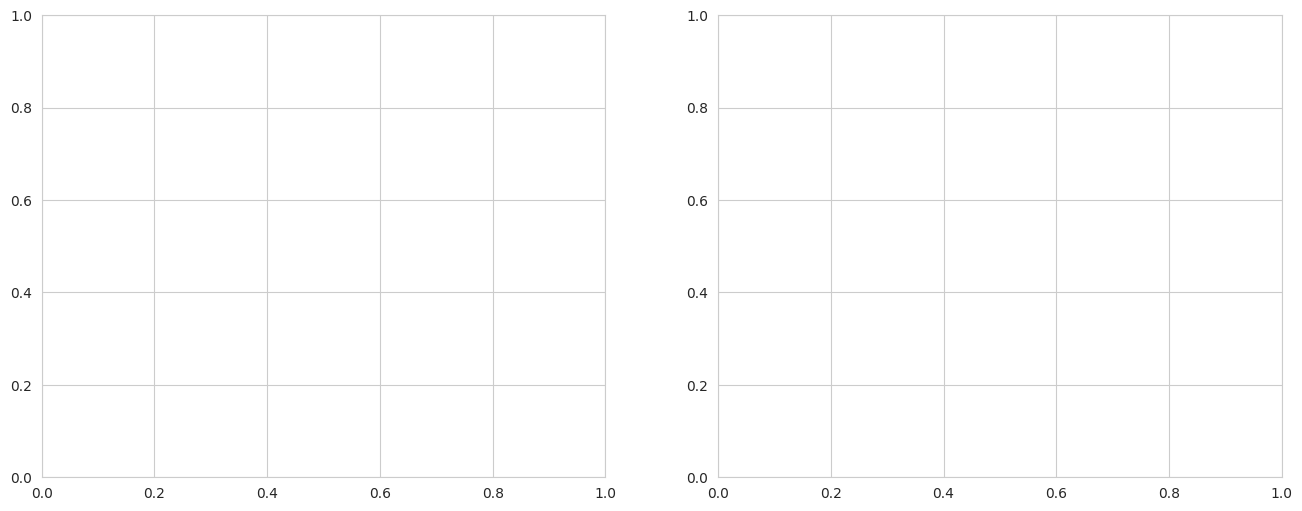

In [ ]:
# ==================== VISUALIZATION ====================
print("\nGenerating visualizations...")

# 1. Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Train set
ax = axes[0]
scatter = ax.scatter(y_reg_train, y_pred_reg_train,
                     c=X_train_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([y_reg_train.min(), y_reg_train.max()],
        [y_reg_train.min(), y_reg_train.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Train Set\nRMSE: {train_rmse:.3f}, MAE: {train_mae:.3f}, R²: {train_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

# Test set
ax = axes[1]
scatter = ax.scatter(y_reg_test, y_pred_reg_test,
                     c=X_test_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([y_reg_test.min(), y_reg_test.max()],
        [y_reg_test.min(), y_reg_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Test Set\nRMSE: {test_rmse:.3f}, MAE: {test_mae:.3f}, R²: {test_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend()
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_predictions.png")
plt.close()

# 2. Residual plot
fig, ax = plt.subplots(figsize=(12, 6))
residuals_test = y_reg_test - y_pred_reg_test
scatter = ax.scatter(y_pred_reg_test, residuals_test,
                     c=X_test_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted LOS (days)', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('Residual Plot (Test Set)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')
plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_residuals.png")
plt.close()

# 3. Feature importance plot
fig, ax = plt.subplots(figsize=(10, 12))
top_features = importance_df.head(30)
colors = ['red' if feat in classifier_features else 'steelblue'
          for feat in top_features['feature']]
ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('Top 30 Feature Importances\n(Red = Classifier Predictions)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_feature_importance.png")
plt.close()

print("\n" + "="*70)
print("STAGE 2B COMPLETE")
print("="*70)

##**STAGE 3: Comprehensive Comparison & Visualization**
- Run this AFTER both CatBoost and LightGBM models are trained

In [ ]:
# @title
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("STAGE 3: COMPREHENSIVE MODEL COMPARISON")
print("="*70)

# Load threshold configuration
import json
with open('/content/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)

THRESHOLD = threshold_config['threshold']
print(f"\n📊 Classification Threshold: {THRESHOLD:.1f} days ({threshold_config['threshold_type']})")
print(f"   Mean LOS: {threshold_config['mean_los']:.2f} days")
print(f"   Std Dev: {threshold_config['std_los']:.2f} days")
print(f"   Skewness: {threshold_config['skewness']:.2f}")

# ==================== LOAD ALL SAVED MODELS AND RESULTS ====================
print("\nLoading saved models and results...")

# CatBoost - Single Regressor Approach
cb_clf = joblib.load('models/catboost_classifier.pkl')
cb_reg_single = joblib.load('models/catboost_regressor_single.pkl')

# LightGBM - Single Regressor Approach
lgb_clf = joblib.load('models/lgb_classifier.pkl')
lgb_reg_single = joblib.load('models/lgb_regressor_single.pkl')

print("✓ All models loaded successfully")

# ==================== CREATE COMPREHENSIVE COMPARISON TABLE ====================
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_data = {
    'Model Component': [
        'Classifier (AUC-ROC)',
        'Single Regressor (RMSE)',
        'Single Regressor (MAE)',
        'Single Regressor (R²)',
    ],
    'CatBoost': [
        f"{cb_clf['test_auc']:.4f}",
        f"{cb_reg_single['test_rmse']:.4f}",
        f"{cb_reg_single['test_mae']:.4f}",
        f"{cb_reg_single['test_r2']:.4f}",
    ],
    'LightGBM': [
        f"{lgb_clf['test_auc']:.4f}",
        f"{lgb_reg_single['test_rmse']:.4f}",
        f"{lgb_reg_single['test_mae']:.4f}",
        f"{lgb_reg_single['test_r2']:.4f}",
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Save comparison table
comparison_df.to_csv('plots/model_comparison_table.csv', index=False)
print("\n✓ Comparison table saved to 'plots/model_comparison_table.csv'")

# ==================== VISUALIZATION 1: OVERALL MODEL COMPARISON ====================
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Single Regressor LOS Prediction: CatBoost vs LightGBM',
             fontsize=18, fontweight='bold', y=0.98)

models = ['CatBoost', 'LightGBM']
colors = ['#FF6B6B', '#4ECDC4']

# 1. Classifier AUC
ax = axes[0, 0]
aucs = [cb_clf['test_auc'], lgb_clf['test_auc']]
bars = ax.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
ax.set_title('Classifier Performance\n(Short vs Long Stay)', fontsize=13, fontweight='bold')
ax.set_ylim([min(aucs) - 0.02, max(aucs) + 0.02])
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if aucs[0] > aucs[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 2. Single Regressor RMSE
ax = axes[0, 1]
rmses = [cb_reg_single['test_rmse'], lgb_reg_single['test_rmse']]
bars = ax.bar(models, rmses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('RMSE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest RMSE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if rmses[0] < rmses[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 3. Single Regressor MAE
ax = axes[1, 0]
maes = [cb_reg_single['test_mae'], lgb_reg_single['test_mae']]
bars = ax.bar(models, maes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('MAE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest MAE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, maes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if maes[0] < maes[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 4. Single Regressor R²
ax = axes[1, 1]
r2s = [cb_reg_single['test_r2'], lgb_reg_single['test_r2']]
bars = ax.bar(models, r2s, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest R²', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2s):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if r2s[0] > r2s[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

plt.tight_layout()
plt.savefig('plots/overall_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/overall_model_comparison.png")
plt.close()

# ==================== LOAD TEST PREDICTIONS FOR DETAILED ANALYSIS ====================
# We need to reload the data and generate predictions for visualization
print("\nLoading test data for detailed analysis...")

# Load the original data (same as in training)
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# Apply same feature engineering
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_reg = native_df['length_of_stay']
y_class = native_df['los_class']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Train-test split (same random state)
from sklearn.model_selection import train_test_split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

# Generate predictions for CatBoost
cb_class_pred = cb_clf['model'].predict(X_test)
cb_class_proba = cb_clf['model'].predict_proba(X_test)[:, 1]
X_test_cb_aug = X_test.copy()
X_test_cb_aug['predicted_class'] = cb_class_pred
X_test_cb_aug['predicted_long_stay_prob'] = cb_class_proba
cb_pred = cb_reg_single['model'].predict(X_test_cb_aug)

# Generate predictions for LightGBM
# Convert categorical features for LightGBM
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment_Typology_1'
]
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

X_test_lgb = X_test.copy()
for col in cat_features_cleaned:
    if col in X_test_lgb.columns:
        X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_class_pred = lgb_clf['model'].predict(X_test_lgb)
lgb_class_proba = lgb_clf['model'].predict_proba(X_test_lgb)[:, 1]
X_test_lgb_aug = X_test_lgb.copy()
X_test_lgb_aug['predicted_class'] = lgb_class_pred
X_test_lgb_aug['predicted_long_stay_prob'] = lgb_class_proba
lgb_pred = lgb_reg_single['model'].predict(X_test_lgb_aug)

print("✓ Test predictions generated")

# ==================== VISUALIZATION 2: RESIDUALS COMPARISON ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Residuals: Single Regressor Models',
             fontsize=16, fontweight='bold')

# CatBoost residuals
cb_residuals = y_reg_test.values - cb_pred
axes[0, 0].scatter(cb_pred, cb_residuals,
                   alpha=0.3, s=10, color='#FF6B6B')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 0].set_title(f'CatBoost Single Regressor\nRMSE: {cb_reg_single["test_rmse"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# LightGBM residuals
lgb_residuals = y_reg_test.values - lgb_pred
axes[0, 1].scatter(lgb_pred, lgb_residuals,
                   alpha=0.3, s=10, color='#4ECDC4')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 1].set_title(f'LightGBM Single Regressor\nRMSE: {lgb_reg_single["test_rmse"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residual histograms
axes[1, 0].hist(cb_residuals, bins=50, alpha=0.7, color='#FF6B6B', edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('CatBoost Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].hist(lgb_residuals, bins=50, alpha=0.7, color='#4ECDC4', edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('LightGBM Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/residuals_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/residuals_comparison.png")
plt.close()

# ==================== VISUALIZATION 3: ACTUAL VS PREDICTED ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actual vs Predicted LOS: Single Regressor Models',
             fontsize=16, fontweight='bold')

# Sample for visualization
sample_size = min(10000, len(y_reg_test))
sample_indices = np.random.choice(len(y_reg_test), sample_size, replace=False)

# CatBoost
axes[0].scatter(y_reg_test.values[sample_indices],
                cb_pred[sample_indices],
                alpha=0.3, s=10, color='#FF6B6B')
axes[0].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual LOS (days)', fontsize=12)
axes[0].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[0].set_title(f'CatBoost Single Regressor\nR² = {cb_reg_single["test_r2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# LightGBM
axes[1].scatter(y_reg_test.values[sample_indices],
                lgb_pred[sample_indices],
                alpha=0.3, s=10, color='#4ECDC4')
axes[1].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual LOS (days)', fontsize=12)
axes[1].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[1].set_title(f'LightGBM Single Regressor\nR² = {lgb_reg_single["test_r2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/actual_vs_predicted.png")
plt.close()

# ==================== VISUALIZATION 4: PERFORMANCE BY PREDICTED CLASS ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Breakdown by Predicted Class',
             fontsize=16, fontweight='bold')

# Metrics by class for CatBoost
for idx, (class_val, class_name) in enumerate([(0, 'Short Stay'), (1, 'Long Stay')]):
    ax = axes[idx, 0]
    mask = X_test_cb_aug['predicted_class'] == class_val

    if mask.sum() > 0:
        y_true = y_reg_test.values[mask]
        y_pred = cb_pred[mask]

        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        metrics_names = ['RMSE', 'MAE', 'Mean Actual', 'Mean Predicted']
        metrics_values = [rmse, mae, y_true.mean(), y_pred.mean()]

        bars = ax.bar(metrics_names, metrics_values, color='#FF6B6B', alpha=0.7, edgecolor='black')
        ax.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax.set_title(f'CatBoost - {class_name} (n={mask.sum():,})\nR² = {r2:.4f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, metrics_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.tick_params(axis='x', rotation=15)

# Metrics by class for LightGBM
for idx, (class_val, class_name) in enumerate([(0, 'Short Stay'), (1, 'Long Stay')]):
    ax = axes[idx, 1]
    mask = X_test_lgb_aug['predicted_class'] == class_val

    if mask.sum() > 0:
        y_true = y_reg_test.values[mask]
        y_pred = lgb_pred[mask]

        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        metrics_names = ['RMSE', 'MAE', 'Mean Actual', 'Mean Predicted']
        metrics_values = [rmse, mae, y_true.mean(), y_pred.mean()]

        bars = ax.bar(metrics_names, metrics_values, color='#4ECDC4', alpha=0.7, edgecolor='black')
        ax.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax.set_title(f'LightGBM - {class_name} (n={mask.sum():,})\nR² = {r2:.4f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, metrics_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plots/performance_by_class.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/performance_by_class.png")
plt.close()

# ==================== FINAL SUMMARY ====================
print("\n" + "="*70)
print("🎉 COMPREHENSIVE ANALYSIS COMPLETE!")
print("="*70)

print("\nSaved Visualizations:")
print("  1. plots/overall_model_comparison.png - High-level comparison")
print("  2. plots/residuals_comparison.png - Error analysis")
print("  3. plots/actual_vs_predicted.png - Prediction accuracy")
print("  4. plots/performance_by_class.png - Performance breakdown by predicted class")
print("  5. plots/model_comparison_table.csv - Numerical results")

print("\n" + "="*70)
print("WINNER DETERMINATION")
print("="*70)

# Count wins
cb_wins = 0
lgb_wins = 0

metrics_to_compare = [
    (cb_clf['test_auc'], lgb_clf['test_auc'], 'higher', 'Classifier AUC'),
    (cb_reg_single['test_rmse'], lgb_reg_single['test_rmse'], 'lower', 'Regressor RMSE'),
    (cb_reg_single['test_mae'], lgb_reg_single['test_mae'], 'lower', 'Regressor MAE'),
    (cb_reg_single['test_r2'], lgb_reg_single['test_r2'], 'higher', 'Regressor R²'),
]

print("\nMetric-by-Metric Comparison:")
for cb_val, lgb_val, direction, name in metrics_to_compare:
    if direction == 'lower':
        winner = 'CatBoost' if cb_val < lgb_val else 'LightGBM'
        if cb_val < lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1
    else:
        winner = 'CatBoost' if cb_val > lgb_val else 'LightGBM'
        if cb_val > lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1

    print(f"  {name}: {winner} wins")
    print(f"    CatBoost: {cb_val:.4f} | LightGBM: {lgb_val:.4f}")

print(f"\n{'='*70}")
if cb_wins > lgb_wins:
    print(f"🏆 OVERALL WINNER: CatBoost ({cb_wins}/{len(metrics_to_compare)} metrics)")
elif lgb_wins > cb_wins:
    print(f"🏆 OVERALL WINNER: LightGBM ({lgb_wins}/{len(metrics_to_compare)} metrics)")
else:
    print(f"🤝 TIE: Both models won {cb_wins}/{len(metrics_to_compare)} metrics")
print("="*70)

print("\nKey Takeaways:")
print("  • Single regressor approach uses classifier predictions as features")
print("  • Classifier probabilities provide valuable uncertainty information")
print("  • Model learns optimal usage of classification output")
print(f"  • Best model achieves RMSE of ~{min(cb_reg_single['test_rmse'], lgb_reg_single['test_rmse']):.2f} days")
print("  • Both models handle high-cardinality categorical features natively")
print("  • Simpler architecture compared to two separate regressors")

In [ ]:
import pandas as pd
import numpy as np
import joblib
import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score, roc_curve,
    mean_squared_error, mean_absolute_error, r2_score
)
import matplotlib.pyplot as plt
import seaborn as sns
import optuna
import os
import json

In [ ]:
# @title
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import shap
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots_v2', exist_ok=True)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("STAGE 3: COMPREHENSIVE MODEL COMPARISON WITH SHAP ANALYSIS")
print("="*70)

# Load threshold configuration
import json
with open('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)

THRESHOLD = threshold_config['threshold']
print(f"\n📊 Classification Threshold: {THRESHOLD:.1f} days ({threshold_config['threshold_type']})")
print(f"   Mean LOS: {threshold_config['mean_los']:.2f} days")
print(f"   Std Dev: {threshold_config['std_los']:.2f} days")
print(f"   Skewness: {threshold_config['skewness']:.2f}")

# ==================== LOAD ALL SAVED MODELS AND RESULTS ====================
print("\nLoading saved models and results...")

# CatBoost - Single Regressor Approach
cb_clf = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_classifier.pkl')
cb_reg_single = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_regressor_single10k.pkl')
# LightGBM - Single Regressor Approach
lgb_clf = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_classifier.pkl')
lgb_reg_single = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_regressor_single-2.pkl')

print("✓ All models loaded successfully")

# ==================== CREATE COMPREHENSIVE COMPARISON TABLE ====================
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_data = {
    'Model Component': [
        'Classifier (AUC-ROC)',
        'Single Regressor (RMSE)',
        'Single Regressor (MAE)',
        'Single Regressor (R²)',
    ],
    'CatBoost': [
        f"{cb_clf['test_auc']:.4f}",
        f"{cb_reg_single['test_rmse']:.4f}",
        f"{cb_reg_single['test_mae']:.4f}",
        f"{cb_reg_single['test_r2']:.4f}",
    ],
    'LightGBM': [
        f"{lgb_clf['test_auc']:.4f}",
        f"{lgb_reg_single['test_rmse']:.4f}",
        f"{lgb_reg_single['test_mae']:.4f}",
        f"{lgb_reg_single['test_r2']:.4f}",
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Save comparison table
comparison_df.to_csv('plots/model_comparison_table.csv', index=False)
print("\n✓ Comparison table saved to 'plots/model_comparison_table.csv'")

# ==================== VISUALIZATION 1: OVERALL MODEL COMPARISON ====================
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Single Regressor LOS Prediction: CatBoost vs LightGBM',
             fontsize=18, fontweight='bold', y=0.98)

models = ['CatBoost', 'LightGBM']
colors = ['#FF6B6B', '#4ECDC4']

# 1. Classifier AUC
ax = axes[0, 0]
aucs = [cb_clf['test_auc'], lgb_clf['test_auc']]
bars = ax.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
ax.set_title('Classifier Performance\n(Short vs Long Stay)', fontsize=13, fontweight='bold')
ax.set_ylim([min(aucs) - 0.02, max(aucs) + 0.02])
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if aucs[0] > aucs[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 2. Single Regressor RMSE
ax = axes[0, 1]
rmses = [cb_reg_single['test_rmse'], lgb_reg_single['test_rmse']]
bars = ax.bar(models, rmses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('RMSE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest RMSE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if rmses[0] < rmses[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 3. Single Regressor MAE
ax = axes[1, 0]
maes = [cb_reg_single['test_mae'], lgb_reg_single['test_mae']]
bars = ax.bar(models, maes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('MAE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest MAE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, maes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if maes[0] < maes[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 4. Single Regressor R²
ax = axes[1, 1]
r2s = [cb_reg_single['test_r2'], lgb_reg_single['test_r2']]
bars = ax.bar(models, r2s, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest R²', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2s):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if r2s[0] > r2s[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

plt.tight_layout()
plt.savefig('plots/overall_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/overall_model_comparison.png")
plt.close()

# ==================== LOAD TEST PREDICTIONS FOR DETAILED ANALYSIS ====================
print("\nLoading test data for detailed analysis...")

# Load the original data
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# Apply same feature engineering
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_reg = native_df['length_of_stay']
y_class = native_df['los_class']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

# Generate predictions for CatBoost
cb_class_pred = cb_clf['model'].predict(X_test)
cb_class_proba = cb_clf['model'].predict_proba(X_test)[:, 1]
X_test_cb_aug = X_test.copy()
X_test_cb_aug['predicted_class'] = cb_class_pred
X_test_cb_aug['predicted_long_stay_prob'] = cb_class_proba
cb_pred = cb_reg_single['model'].predict(X_test_cb_aug)

# Generate predictions for LightGBM
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment_Typology_1'
]
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

X_test_lgb = X_test.copy()
for col in cat_features_cleaned:
    if col in X_test_lgb.columns:
        X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_class_pred = lgb_clf['model'].predict(X_test_lgb)
lgb_class_proba = lgb_clf['model'].predict_proba(X_test_lgb)[:, 1]
X_test_lgb_aug = X_test_lgb.copy()
X_test_lgb_aug['predicted_class'] = lgb_class_pred
X_test_lgb_aug['predicted_long_stay_prob'] = lgb_class_proba
lgb_pred = lgb_reg_single['model'].predict(X_test_lgb_aug)

print("✓ Test predictions generated")



# ==================== VISUALIZATION 2: RESIDUALS COMPARISON ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Residuals: Single Regressor Models',
             fontsize=16, fontweight='bold')

# CatBoost residuals
cb_residuals = y_reg_test.values - cb_pred
axes[0, 0].scatter(cb_pred, cb_residuals,
                   alpha=0.3, s=10, color='#FF6B6B')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 0].set_title(f'CatBoost Single Regressor\nRMSE: {cb_reg_single["test_rmse"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# LightGBM residuals
lgb_residuals = y_reg_test.values - lgb_pred
axes[0, 1].scatter(lgb_pred, lgb_residuals,
                   alpha=0.3, s=10, color='#4ECDC4')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 1].set_title(f'LightGBM Single Regressor\nRMSE: {lgb_reg_single["test_rmse"]:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residual histograms
axes[1, 0].hist(cb_residuals, bins=50, alpha=0.7, color='#FF6B6B', edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('CatBoost Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].hist(lgb_residuals, bins=50, alpha=0.7, color='#4ECDC4', edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('LightGBM Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/residuals_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/residuals_comparison.png")
plt.close()

# ==================== VISUALIZATION 3: ACTUAL VS PREDICTED ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actual vs Predicted LOS: Single Regressor Models',
             fontsize=16, fontweight='bold')

# Sample for visualization
sample_size = min(10000, len(y_reg_test))
sample_indices = np.random.choice(len(y_reg_test), sample_size, replace=False)

# CatBoost
axes[0].scatter(y_reg_test.values[sample_indices],
                cb_pred[sample_indices],
                alpha=0.3, s=10, color='#FF6B6B')
axes[0].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual LOS (days)', fontsize=12)
axes[0].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[0].set_title(f'CatBoost Single Regressor\nR² = {cb_reg_single["test_r2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# LightGBM
axes[1].scatter(y_reg_test.values[sample_indices],
                lgb_pred[sample_indices],
                alpha=0.3, s=10, color='#4ECDC4')
axes[1].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual LOS (days)', fontsize=12)
axes[1].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[1].set_title(f'LightGBM Single Regressor\nR² = {lgb_reg_single["test_r2"]:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/actual_vs_predicted.png")
plt.close()

# ==================== VISUALIZATION 4: PERFORMANCE BY PREDICTED CLASS ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Breakdown by Predicted Class',
             fontsize=16, fontweight='bold')

# Metrics by class for CatBoost
for idx, (class_val, class_name) in enumerate([(0, 'Short Stay'), (1, 'Long Stay')]):
    ax = axes[idx, 0]
    mask = X_test_cb_aug['predicted_class'] == class_val

    if mask.sum() > 0:
        y_true = y_reg_test.values[mask]
        y_pred = cb_pred[mask]

        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        metrics_names = ['RMSE', 'MAE', 'Mean Actual', 'Mean Predicted']
        metrics_values = [rmse, mae, y_true.mean(), y_pred.mean()]

        bars = ax.bar(metrics_names, metrics_values, color='#4ECDC4', alpha=0.7, edgecolor='black')
        ax.set_ylabel('Value', fontsize=11, fontweight='bold')
        ax.set_title(f'LightGBM - {class_name} (n={mask.sum():,})\nR² = {r2:.4f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, metrics_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plots/performance_by_class.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/performance_by_class.png")
plt.close()

# ==================== FINAL SUMMARY ====================
print("\n" + "="*70)
print("🎉 COMPREHENSIVE ANALYSIS COMPLETE!")
print("="*70)

print("\nSaved Visualizations:")
print("  Standard Plots:")
print("    1. plots/overall_model_comparison.png - High-level comparison")
print("    2. plots/residuals_comparison.png - Error analysis")
print("    3. plots/actual_vs_predicted.png - Prediction accuracy")
print("    4. plots/performance_by_class.png - Performance breakdown by predicted class")
print("    5. plots/model_comparison_table.csv - Numerical results")
print("\n  SHAP Plots:")
print("    6. plots/shap_catboost_classifier_summary.png")
print("    7. plots/shap_catboost_classifier_bar.png")
print("    8. plots/shap_catboost_regressor_summary.png")
print("    9. plots/shap_catboost_regressor_bar.png")
print("    10. plots/shap_lightgbm_classifier_summary.png")
print("    11. plots/shap_lightgbm_classifier_bar.png")
print("    12. plots/shap_lightgbm_regressor_summary.png")
print("    13. plots/shap_lightgbm_regressor_bar.png")

print("\n" + "="*70)
print("WINNER DETERMINATION")
print("="*70)

# Count wins
cb_wins = 0
lgb_wins = 0

metrics_to_compare = [
    (cb_clf['test_auc'], lgb_clf['test_auc'], 'higher', 'Classifier AUC'),
    (cb_reg_single['test_rmse'], lgb_reg_single['test_rmse'], 'lower', 'Regressor RMSE'),
    (cb_reg_single['test_mae'], lgb_reg_single['test_mae'], 'lower', 'Regressor MAE'),
    (cb_reg_single['test_r2'], lgb_reg_single['test_r2'], 'higher', 'Regressor R²'),
]

print("\nMetric-by-Metric Comparison:")
for cb_val, lgb_val, direction, name in metrics_to_compare:
    if direction == 'lower':
        winner = 'CatBoost' if cb_val < lgb_val else 'LightGBM'
        if cb_val < lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1
    else:
        winner = 'CatBoost' if cb_val > lgb_val else 'LightGBM'
        if cb_val > lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1

    print(f"  {name}: {winner} wins")
    print(f"    CatBoost: {cb_val:.4f} | LightGBM: {lgb_val:.4f}")

print(f"\n{'='*70}")
if cb_wins > lgb_wins:
    print(f"🏆 OVERALL WINNER: CatBoost ({cb_wins}/{len(metrics_to_compare)} metrics)")
elif lgb_wins > cb_wins:
    print(f"🏆 OVERALL WINNER: LightGBM ({lgb_wins}/{len(metrics_to_compare)} metrics)")
else:
    print(f"🤝 TIE: Both models won {cb_wins}/{len(metrics_to_compare)} metrics")
print("="*70)

print("\nKey Takeaways:")
print("  • Single regressor approach uses classifier predictions as features")
print("  • Classifier probabilities provide valuable uncertainty information")
print("  • Model learns optimal usage of classification output")
print(f"  • Best model achieves RMSE of ~{min(cb_reg_single['test_rmse'], lgb_reg_single['test_rmse']):.2f} days")
print("  • Both models handle high-cardinality categorical features natively")
print("  • Simpler architecture compared to two separate regressors")
print("  • SHAP analysis reveals most important features for predictions")

STAGE 3: COMPREHENSIVE MODEL COMPARISON WITH SHAP ANALYSIS

📊 Classification Threshold: 3.0 days (median)
   Mean LOS: 6.23 days
   Std Dev: 9.25 days
   Skewness: 5.70

Loading saved models and results...
✓ All models loaded successfully

MODEL PERFORMANCE COMPARISON

        Model Component CatBoost LightGBM
   Classifier (AUC-ROC)   0.8871   0.8928
Single Regressor (RMSE)   6.6454   6.6218
 Single Regressor (MAE)   3.0843   3.0573
  Single Regressor (R²)   0.4799   0.4836

✓ Comparison table saved to 'plots/model_comparison_table.csv'

Generating visualizations...
✓ Saved: plots/overall_model_comparison.png

Loading test data for detailed analysis...
✓ Test predictions generated
✓ Saved: plots/residuals_comparison.png
✓ Saved: plots/actual_vs_predicted.png
✓ Saved: plots/performance_by_class.png

🎉 COMPREHENSIVE ANALYSIS COMPLETE!

Saved Visualizations:
  Standard Plots:
    1. plots/overall_model_comparison.png - High-level comparison
    2. plots/residuals_comparison.png - Error a

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, roc_curve, roc_auc_score
import shap
import os

# Create directories
os.makedirs('models', exist_ok=True)
os.makedirs('plots', exist_ok=True)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("STAGE 3: COMPREHENSIVE MODEL COMPARISON WITH SHAP ANALYSIS")
print("="*70)

# Load threshold configuration
import json
with open('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/threshold_config.json', 'r') as f:
    threshold_config = json.load(f)

THRESHOLD = threshold_config['threshold']
print(f"\n📊 Classification Threshold: {THRESHOLD:.1f} days ({threshold_config['threshold_type']})")
print(f"   Mean LOS: {threshold_config['mean_los']:.2f} days")
print(f"   Std Dev: {threshold_config['std_los']:.2f} days")
print(f"   Skewness: {threshold_config['skewness']:.2f}")

# ==================== LOAD ALL SAVED MODELS AND RESULTS ====================
print("\nLoading saved models and results...")

# CatBoost - Single Regressor Approach
cb_clf = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_classifier.pkl')
cb_reg_single = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/catboost_regressor_single10k.pkl')
# LightGBM - Single Regressor Approach
lgb_clf = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_classifier.pkl')
lgb_reg_single = joblib.load('/content/drive/MyDrive/Sparcs_Datafiles/Hanna - Saved Models/Two stage models/lgb_regressor_single-2.pkl')

print("✓ All models loaded successfully")

# ==================== CREATE COMPREHENSIVE COMPARISON TABLE ====================
print("\n" + "="*70)
print("MODEL PERFORMANCE COMPARISON")
print("="*70)

comparison_data = {
    'Model Component': [
        'Classifier (AUC-ROC)',
        'Single Regressor (RMSE)',
        'Single Regressor (MAE)',
        'Single Regressor (R²)',
    ],
    'CatBoost': [
        f"{cb_clf['test_auc']:.4f}",
        f"{cb_reg_single['test_rmse']:.4f}",
        f"{cb_reg_single['test_mae']:.4f}",
        f"{cb_reg_single['test_r2']:.4f}",
    ],
    'LightGBM': [
        f"{lgb_clf['test_auc']:.4f}",
        f"{lgb_reg_single['test_rmse']:.4f}",
        f"{lgb_reg_single['test_mae']:.4f}",
        f"{lgb_reg_single['test_r2']:.4f}",
    ]
}

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Save comparison table
comparison_df.to_csv('plots/model_comparison_table.csv', index=False)
print("\n✓ Comparison table saved to 'plots/model_comparison_table.csv'")

# ==================== VISUALIZATION 1: OVERALL MODEL COMPARISON ====================
print("\nGenerating visualizations...")

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Single Regressor LOS Prediction: CatBoost vs LightGBM',
             fontsize=18, fontweight='bold', y=0.98)

models = ['CatBoost', 'LightGBM']
colors = ['#FF6B6B', '#4ECDC4']

# 1. Classifier AUC
ax = axes[0, 0]
aucs = [cb_clf['test_auc'], lgb_clf['test_auc']]
bars = ax.bar(models, aucs, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('AUC-ROC', fontsize=12, fontweight='bold')
ax.set_title('Classifier Performance\n(Short vs Long Stay)', fontsize=13, fontweight='bold')
ax.set_ylim([min(aucs) - 0.02, max(aucs) + 0.02])
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, aucs):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height + 0.002,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if aucs[0] > aucs[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 2. Single Regressor RMSE
ax = axes[0, 1]
rmses = [cb_reg_single['test_rmse'], lgb_reg_single['test_rmse']]
bars = ax.bar(models, rmses, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('RMSE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest RMSE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, rmses):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if rmses[0] < rmses[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 3. Single Regressor MAE
ax = axes[1, 0]
maes = [cb_reg_single['test_mae'], lgb_reg_single['test_mae']]
bars = ax.bar(models, maes, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('MAE (days)', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest MAE', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, maes):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if maes[0] < maes[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

# 4. Single Regressor R²
ax = axes[1, 1]
r2s = [cb_reg_single['test_r2'], lgb_reg_single['test_r2']]
bars = ax.bar(models, r2s, color=colors, alpha=0.7, edgecolor='black', linewidth=2)
ax.set_ylabel('R²', fontsize=12, fontweight='bold')
ax.set_title('Single Regressor\nTest R²', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='y')
for bar, val in zip(bars, r2s):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
if r2s[0] > r2s[1]:
    bars[0].set_edgecolor('gold')
    bars[0].set_linewidth(4)
else:
    bars[1].set_edgecolor('gold')
    bars[1].set_linewidth(4)

plt.tight_layout()
plt.savefig('plots/overall_model_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/overall_model_comparison.png")
plt.close()

# ==================== LOAD TEST PREDICTIONS FOR DETAILED ANALYSIS ====================
print("\nLoading test data for detailed analysis...")

# Load the original data
df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# Apply same feature engineering
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)

native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_reg = native_df['length_of_stay']
y_class = native_df['los_class']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

# ==================== GENERATE PREDICTIONS WITH CLIPPING ====================
print("\nGenerating predictions...")

# Generate predictions for CatBoost
cb_class_pred = cb_clf['model'].predict(X_test)
cb_class_proba = cb_clf['model'].predict_proba(X_test)[:, 1]
X_test_cb_aug = X_test.copy()
X_test_cb_aug['predicted_class'] = cb_class_pred
X_test_cb_aug['predicted_long_stay_prob'] = cb_class_proba
cb_pred_raw = cb_reg_single['model'].predict(X_test_cb_aug)

# 🔥 FIX: Clip negative predictions to 0
cb_pred = np.maximum(cb_pred_raw, 0)
num_negative_cb = (cb_pred_raw < 0).sum()
print(f"  CatBoost: {num_negative_cb:,} negative predictions corrected to 0")

# Generate predictions for LightGBM
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment_Typology_1'
]
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

X_test_lgb = X_test.copy()
for col in cat_features_cleaned:
    if col in X_test_lgb.columns:
        X_test_lgb[col] = X_test_lgb[col].astype('category')

lgb_class_pred = lgb_clf['model'].predict(X_test_lgb)
lgb_class_proba = lgb_clf['model'].predict_proba(X_test_lgb)[:, 1]
X_test_lgb_aug = X_test_lgb.copy()
X_test_lgb_aug['predicted_class'] = lgb_class_pred
X_test_lgb_aug['predicted_long_stay_prob'] = lgb_class_proba
lgb_pred_raw = lgb_reg_single['model'].predict(X_test_lgb_aug)

# 🔥 FIX: Clip negative predictions to 0
lgb_pred = np.maximum(lgb_pred_raw, 0)
num_negative_lgb = (lgb_pred_raw < 0).sum()
print(f"  LightGBM: {num_negative_lgb:,} negative predictions corrected to 0")

# ==================== RECALCULATE METRICS WITH CORRECTED PREDICTIONS ====================
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# CatBoost corrected metrics
cb_mae_corrected = mean_absolute_error(y_reg_test.values, cb_pred)
cb_rmse_corrected = np.sqrt(mean_squared_error(y_reg_test.values, cb_pred))
cb_r2_corrected = r2_score(y_reg_test.values, cb_pred)

# LightGBM corrected metrics
lgb_mae_corrected = mean_absolute_error(y_reg_test.values, lgb_pred)
lgb_rmse_corrected = np.sqrt(mean_squared_error(y_reg_test.values, lgb_pred))
lgb_r2_corrected = r2_score(y_reg_test.values, lgb_pred)

print("\n" + "="*70)
print("CORRECTED METRICS (After removing negative predictions)")
print("="*70)
print(f"\nCatBoost:")
print(f"  MAE:  {cb_mae_corrected:.4f} (was {cb_reg_single['test_mae']:.4f})")
print(f"  RMSE: {cb_rmse_corrected:.4f} (was {cb_reg_single['test_rmse']:.4f})")
print(f"  R²:   {cb_r2_corrected:.4f} (was {cb_reg_single['test_r2']:.4f})")

print(f"\nLightGBM:")
print(f"  MAE:  {lgb_mae_corrected:.4f} (was {lgb_reg_single['test_mae']:.4f})")
print(f"  RMSE: {lgb_rmse_corrected:.4f} (was {lgb_reg_single['test_rmse']:.4f})")
print(f"  R²:   {lgb_r2_corrected:.4f} (was {lgb_reg_single['test_r2']:.4f})")

print("✓ Test predictions generated")

# ==================== SHAP ANALYSIS ====================
print("\n" + "="*70)
print("GENERATING SHAP ANALYSIS")
print("="*70)

# Sample data for SHAP (use smaller sample for faster computation)
shap_sample_size = min(1000, len(X_test))
shap_sample_indices = np.random.choice(len(X_test), shap_sample_size, replace=False)

print(f"\nUsing {shap_sample_size} samples for SHAP analysis...")

# ==================== SHAP FOR CATBOOST CLASSIFIER ====================
print("\n1. Computing SHAP values for CatBoost Classifier...")
X_test_cb_sample = X_test.iloc[shap_sample_indices]

try:
    cb_clf_explainer = shap.TreeExplainer(cb_clf['model'])
    cb_clf_shap_values = cb_clf_explainer.shap_values(X_test_cb_sample)

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(cb_clf_shap_values, X_test_cb_sample,
                      max_display=20, show=False)
    plt.title('CatBoost Classifier - SHAP Feature Importance',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_catboost_classifier_summary.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_catboost_classifier_summary.png")
    plt.close()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(cb_clf_shap_values, X_test_cb_sample,
                      plot_type="bar", max_display=20, show=False)
    plt.title('CatBoost Classifier - Mean SHAP Values',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_catboost_classifier_bar.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_catboost_classifier_bar.png")
    plt.close()

except Exception as e:
    print(f"⚠ Error computing CatBoost classifier SHAP: {e}")

# ==================== SHAP FOR CATBOOST REGRESSOR ====================
print("\n2. Computing SHAP values for CatBoost Regressor...")
X_test_cb_aug_sample = X_test_cb_aug.iloc[shap_sample_indices]

try:
    cb_reg_explainer = shap.TreeExplainer(cb_reg_single['model'])
    cb_reg_shap_values = cb_reg_explainer.shap_values(X_test_cb_aug_sample)

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(cb_reg_shap_values, X_test_cb_aug_sample,
                      max_display=20, show=False)
    plt.title('CatBoost Regressor - SHAP Feature Importance',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_catboost_regressor_summary.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_catboost_regressor_summary.png")
    plt.close()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(cb_reg_shap_values, X_test_cb_aug_sample,
                      plot_type="bar", max_display=20, show=False)
    plt.title('CatBoost Regressor - Mean SHAP Values',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_catboost_regressor_bar.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_catboost_regressor_bar.png")
    plt.close()

except Exception as e:
    print(f"⚠ Error computing CatBoost regressor SHAP: {e}")

# ==================== SHAP FOR LIGHTGBM CLASSIFIER ====================
print("\n3. Computing SHAP values for LightGBM Classifier...")
X_test_lgb_sample = X_test_lgb.iloc[shap_sample_indices]

try:
    lgb_clf_explainer = shap.TreeExplainer(lgb_clf['model'])
    lgb_clf_shap_values = lgb_clf_explainer.shap_values(X_test_lgb_sample)

    # For binary classification, SHAP returns values for both classes
    # Use class 1 (long stay) for visualization
    if isinstance(lgb_clf_shap_values, list):
        lgb_clf_shap_values = lgb_clf_shap_values[1]

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(lgb_clf_shap_values, X_test_lgb_sample,
                      max_display=20, show=False)
    plt.title('LightGBM Classifier - SHAP Feature Importance',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_lightgbm_classifier_summary.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_lightgbm_classifier_summary.png")
    plt.close()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(lgb_clf_shap_values, X_test_lgb_sample,
                      plot_type="bar", max_display=20, show=False)
    plt.title('LightGBM Classifier - Mean SHAP Values',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_lightgbm_classifier_bar.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_lightgbm_classifier_bar.png")
    plt.close()

except Exception as e:
    print(f"⚠ Error computing LightGBM classifier SHAP: {e}")

# ==================== SHAP FOR LIGHTGBM REGRESSOR ====================
print("\n4. Computing SHAP values for LightGBM Regressor...")
X_test_lgb_aug_sample = X_test_lgb_aug.iloc[shap_sample_indices]

try:
    lgb_reg_explainer = shap.TreeExplainer(lgb_reg_single['model'])
    lgb_reg_shap_values = lgb_reg_explainer.shap_values(X_test_lgb_aug_sample)

    # Summary plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(lgb_reg_shap_values, X_test_lgb_aug_sample,
                      max_display=20, show=False)
    plt.title('LightGBM Regressor - SHAP Feature Importance',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_lightgbm_regressor_summary.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_lightgbm_regressor_summary.png")
    plt.close()

    # Bar plot
    plt.figure(figsize=(12, 8))
    shap.summary_plot(lgb_reg_shap_values, X_test_lgb_aug_sample,
                      plot_type="bar", max_display=20, show=False)
    plt.title('LightGBM Regressor - Mean SHAP Values',
              fontsize=14, fontweight='bold', pad=20)
    plt.tight_layout()
    plt.savefig('plots/shap_lightgbm_regressor_bar.png', dpi=300, bbox_inches='tight')
    print("✓ Saved: plots/shap_lightgbm_regressor_bar.png")
    plt.close()

except Exception as e:
    print(f"⚠ Error computing LightGBM regressor SHAP: {e}")

print("\n✓ SHAP analysis complete!")

# ==================== VISUALIZATION 2: RESIDUALS COMPARISON ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Prediction Residuals: Single Regressor Models (Corrected)',
             fontsize=16, fontweight='bold')

# CatBoost residuals
cb_residuals = y_reg_test.values - cb_pred
axes[0, 0].scatter(cb_pred, cb_residuals,
                   alpha=0.3, s=10, color='#FF6B6B')
axes[0, 0].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 0].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 0].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 0].set_title(f'CatBoost Single Regressor\nRMSE: {cb_rmse_corrected:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)

# LightGBM residuals
lgb_residuals = y_reg_test.values - lgb_pred
axes[0, 1].scatter(lgb_pred, lgb_residuals,
                   alpha=0.3, s=10, color='#4ECDC4')
axes[0, 1].axhline(y=0, color='black', linestyle='--', linewidth=2)
axes[0, 1].set_xlabel('Predicted LOS (days)', fontsize=11)
axes[0, 1].set_ylabel('Residuals (days)', fontsize=11)
axes[0, 1].set_title(f'LightGBM Single Regressor\nRMSE: {lgb_rmse_corrected:.4f}',
                     fontsize=12, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)

# Residual histograms
axes[1, 0].hist(cb_residuals, bins=50, alpha=0.7, color='#FF6B6B', edgecolor='black')
axes[1, 0].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 0].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 0].set_ylabel('Frequency', fontsize=11)
axes[1, 0].set_title('CatBoost Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3, axis='y')

axes[1, 1].hist(lgb_residuals, bins=50, alpha=0.7, color='#4ECDC4', edgecolor='black')
axes[1, 1].axvline(x=0, color='black', linestyle='--', linewidth=2)
axes[1, 1].set_xlabel('Residuals (days)', fontsize=11)
axes[1, 1].set_ylabel('Frequency', fontsize=11)
axes[1, 1].set_title('LightGBM Residuals Distribution', fontsize=12, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('plots/residuals_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/residuals_comparison.png")
plt.close()

# ==================== VISUALIZATION 3: ACTUAL VS PREDICTED ====================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Actual vs Predicted LOS: Single Regressor Models (Corrected)',
             fontsize=16, fontweight='bold')

# Sample for visualization
sample_size = min(10000, len(y_reg_test))
sample_indices = np.random.choice(len(y_reg_test), sample_size, replace=False)

# CatBoost
axes[0].scatter(y_reg_test.values[sample_indices],
                cb_pred[sample_indices],
                alpha=0.3, s=10, color='#FF6B6B')
axes[0].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[0].set_xlabel('Actual LOS (days)', fontsize=12)
axes[0].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[0].set_title(f'CatBoost Single Regressor\nR² = {cb_r2_corrected:.4f}',
                  fontsize=13, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim(left=0)  # 🔥 Ensure x-axis starts at 0
axes[0].set_ylim(bottom=0)  # 🔥 Ensure y-axis starts at 0

# LightGBM
axes[1].scatter(y_reg_test.values[sample_indices],
                lgb_pred[sample_indices],
                alpha=0.3, s=10, color='#4ECDC4')
axes[1].plot([0, y_reg_test.max()],
             [0, y_reg_test.max()],
             'k--', linewidth=2, label='Perfect Prediction')
axes[1].set_xlabel('Actual LOS (days)', fontsize=12)
axes[1].set_ylabel('Predicted LOS (days)', fontsize=12)
axes[1].set_title(f'LightGBM Single Regressor\nR² = {lgb_r2_corrected:.4f}',
                  fontsize=13, fontweight='bold')
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim(left=0)  # 🔥 Ensure x-axis starts at 0
axes[1].set_ylim(bottom=0)  # 🔥 Ensure y-axis starts at 0

plt.tight_layout()
plt.savefig('plots/actual_vs_predicted.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/actual_vs_predicted.png")
plt.close()

# ==================== VISUALIZATION 4: PERFORMANCE BY PREDICTED CLASS ====================
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Performance Breakdown by Predicted Class (Corrected)',
             fontsize=16, fontweight='bold')

# Metrics by class for CatBoost
for idx, (class_val, class_name) in enumerate([(0, 'Short Stay'), (1, 'Long Stay')]):
    ax = axes[idx, 0]
    mask = X_test_cb_aug['predicted_class'] == class_val

    if mask.sum() > 0:
        y_true = y_reg_test.values[mask]
        y_pred = cb_pred[mask]

        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        metrics_names = ['RMSE', 'MAE', 'Mean Actual', 'Mean Predicted']
        metrics_values = [rmse, mae, y_true.mean(), y_pred.mean()]

        bars = ax.bar(metrics_names, metrics_values, color='#FF6B6B', alpha=0.7, edgecolor='black')
        ax.set_ylabel('Value (days)', fontsize=11, fontweight='bold')
        ax.set_title(f'CatBoost - {class_name} (n={mask.sum():,})\nR² = {r2:.4f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, metrics_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.tick_params(axis='x', rotation=15)

# Metrics by class for LightGBM
for idx, (class_val, class_name) in enumerate([(0, 'Short Stay'), (1, 'Long Stay')]):
    ax = axes[idx, 1]
    mask = X_test_lgb_aug['predicted_class'] == class_val

    if mask.sum() > 0:
        y_true = y_reg_test.values[mask]
        y_pred = lgb_pred[mask]

        from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
        rmse = np.sqrt(mean_squared_error(y_true, y_pred))
        mae = mean_absolute_error(y_true, y_pred)
        r2 = r2_score(y_true, y_pred)

        metrics_names = ['RMSE', 'MAE', 'Mean Actual', 'Mean Predicted']
        metrics_values = [rmse, mae, y_true.mean(), y_pred.mean()]

        bars = ax.bar(metrics_names, metrics_values, color='#4ECDC4', alpha=0.7, edgecolor='black')
        ax.set_ylabel('Value (days)', fontsize=11, fontweight='bold')
        ax.set_title(f'LightGBM - {class_name} (n={mask.sum():,})\nR² = {r2:.4f}',
                    fontsize=12, fontweight='bold')
        ax.grid(True, alpha=0.3, axis='y')

        for bar, val in zip(bars, metrics_values):
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

        ax.tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig('plots/performance_by_class.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/performance_by_class.png")
plt.close()

# ==================== FINAL SUMMARY ====================
print("\n" + "="*70)
print("🎉 COMPREHENSIVE ANALYSIS COMPLETE!")
print("="*70)

print("\nSaved Visualizations:")
print("  Standard Plots:")
print("    1. plots/overall_model_comparison.png - High-level comparison")
print("    2. plots/residuals_comparison.png - Error analysis")
print("    3. plots/actual_vs_predicted.png - Prediction accuracy")
print("    4. plots/performance_by_class.png - Performance breakdown by predicted class")
print("    5. plots/model_comparison_table.csv - Numerical results")
print("\n  SHAP Plots:")
print("    6. plots/shap_catboost_classifier_summary.png")
print("    7. plots/shap_catboost_classifier_bar.png")
print("    8. plots/shap_catboost_regressor_summary.png")
print("    9. plots/shap_catboost_regressor_bar.png")
print("    10. plots/shap_lightgbm_classifier_summary.png")
print("    11. plots/shap_lightgbm_classifier_bar.png")
print("    12. plots/shap_lightgbm_regressor_summary.png")
print("    13. plots/shap_lightgbm_regressor_bar.png")

print("\n" + "="*70)
print("WINNER DETERMINATION (With Corrected Predictions)")
print("="*70)

# Count wins
cb_wins = 0
lgb_wins = 0

metrics_to_compare = [
    (cb_clf['test_auc'], lgb_clf['test_auc'], 'higher', 'Classifier AUC'),
    (cb_rmse_corrected, lgb_rmse_corrected, 'lower', 'Regressor RMSE'),
    (cb_mae_corrected, lgb_mae_corrected, 'lower', 'Regressor MAE'),
    (cb_r2_corrected, lgb_r2_corrected, 'higher', 'Regressor R²'),
]

print("\nMetric-by-Metric Comparison:")
for cb_val, lgb_val, direction, name in metrics_to_compare:
    if direction == 'lower':
        winner = 'CatBoost' if cb_val < lgb_val else 'LightGBM'
        if cb_val < lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1
    else:
        winner = 'CatBoost' if cb_val > lgb_val else 'LightGBM'
        if cb_val > lgb_val:
            cb_wins += 1
        else:
            lgb_wins += 1

    print(f"  {name}: {winner} wins")
    print(f"    CatBoost: {cb_val:.4f} | LightGBM: {lgb_val:.4f}")

print(f"\n{'='*70}")
if cb_wins > lgb_wins:
    print(f"🏆 OVERALL WINNER: CatBoost ({cb_wins}/{len(metrics_to_compare)} metrics)")
elif lgb_wins > cb_wins:
    print(f"🏆 OVERALL WINNER: LightGBM ({lgb_wins}/{len(metrics_to_compare)} metrics)")
else:
    print(f"🤝 TIE: Both models won {cb_wins}/{len(metrics_to_compare)} metrics")
print("="*70)

print("\nKey Takeaways:")
print("  • Single regressor approach uses classifier predictions as features")
print("  • Classifier probabilities provide valuable uncertainty information")
print("  • Model learns optimal usage of classification output")
print(f"  • Best model achieves RMSE of ~{min(cb_rmse_corrected, lgb_rmse_corrected):.2f} days")
print("  • Both models handle high-cardinality categorical features natively")
print("  • Simpler architecture compared to two separate regressors")
print("  • SHAP analysis reveals most important features for predictions")
print(f"  • Negative predictions corrected: CatBoost={num_negative_cb:,}, LightGBM={num_negative_lgb:,}")

STAGE 3: COMPREHENSIVE MODEL COMPARISON WITH SHAP ANALYSIS

📊 Classification Threshold: 3.0 days (median)
   Mean LOS: 6.23 days
   Std Dev: 9.25 days
   Skewness: 5.70

Loading saved models and results...
✓ All models loaded successfully

MODEL PERFORMANCE COMPARISON

        Model Component CatBoost LightGBM
   Classifier (AUC-ROC)   0.8871   0.8928
Single Regressor (RMSE)   6.6454   6.6218
 Single Regressor (MAE)   3.0843   3.0573
  Single Regressor (R²)   0.4799   0.4836

✓ Comparison table saved to 'plots/model_comparison_table.csv'

Generating visualizations...
✓ Saved: plots/overall_model_comparison.png

Loading test data for detailed analysis...

Generating predictions...
  CatBoost: 48 negative predictions corrected to 0
  LightGBM: 16 negative predictions corrected to 0

CORRECTED METRICS (After removing negative predictions)

CatBoost:
  MAE:  3.0842 (was 3.0843)
  RMSE: 6.6453 (was 6.6454)
  R²:   0.4799 (was 0.4799)

LightGBM:
  MAE:  3.0573 (was 3.0573)
  RMSE: 6.6217 (wa

/usr/local/lib/python3.12/dist-packages/shap/explainers/_tree.py:587: UserWarning: LightGBM binary classifier with TreeExplainer shap values output has changed to a list of ndarray
  warnings.warn(


✓ Saved: plots/shap_lightgbm_classifier_summary.png
✓ Saved: plots/shap_lightgbm_classifier_bar.png

4. Computing SHAP values for LightGBM Regressor...
✓ Saved: plots/shap_lightgbm_regressor_summary.png
✓ Saved: plots/shap_lightgbm_regressor_bar.png

✓ SHAP analysis complete!
✓ Saved: plots/residuals_comparison.png
✓ Saved: plots/actual_vs_predicted.png
✓ Saved: plots/performance_by_class.png

🎉 COMPREHENSIVE ANALYSIS COMPLETE!

Saved Visualizations:
  Standard Plots:
    1. plots/overall_model_comparison.png - High-level comparison
    2. plots/residuals_comparison.png - Error analysis
    3. plots/actual_vs_predicted.png - Prediction accuracy
    4. plots/performance_by_class.png - Performance breakdown by predicted class
    5. plots/model_comparison_table.csv - Numerical results

  SHAP Plots:
    6. plots/shap_catboost_classifier_summary.png
    7. plots/shap_catboost_classifier_bar.png
    8. plots/shap_catboost_regressor_summary.png
    9. plots/shap_catboost_regressor_bar.png
 

In [ ]:
# ==================== VISUALIZATION 5: CONFUSION MATRICES FOR CLASSIFIERS ====================
print("\n" + "="*70)
print("GENERATING CONFUSION MATRICES")
print("="*70)

from sklearn.metrics import confusion_matrix, classification_report

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle(f'Classifier Confusion Matrices (Threshold: {THRESHOLD:.1f} days)',
             fontsize=16, fontweight='bold')

# CatBoost Classifier Confusion Matrix
cb_cm = confusion_matrix(y_class_test, cb_class_pred)
cb_cm_normalized = cb_cm.astype('float') / cb_cm.sum(axis=1)[:, np.newaxis]

# Plot CatBoost confusion matrix
sns.heatmap(cb_cm, annot=True, fmt='d', cmap='Reds',
            ax=axes[0], cbar=True, square=True,
            xticklabels=['Short Stay\n(≤' + f'{THRESHOLD:.1f}' + ' days)',
                        'Long Stay\n(>' + f'{THRESHOLD:.1f}' + ' days)'],
            yticklabels=['Short Stay\n(≤' + f'{THRESHOLD:.1f}' + ' days)',
                        'Long Stay\n(>' + f'{THRESHOLD:.1f}' + ' days)'],
            linewidths=2, linecolor='black')

# Add percentage annotations
for i in range(2):
    for j in range(2):
        text = axes[0].text(j + 0.5, i + 0.7,
                           f'({cb_cm_normalized[i, j]*100:.1f}%)',
                           ha='center', va='center',
                           fontsize=10, color='white' if cb_cm_normalized[i, j] > 0.5 else 'black',
                           fontweight='bold')

axes[0].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Actual Class', fontsize=12, fontweight='bold')
axes[0].set_title(f'CatBoost Classifier\nAUC-ROC: {cb_clf["test_auc"]:.4f}',
                  fontsize=13, fontweight='bold', pad=15)

# Calculate metrics for CatBoost
cb_tn, cb_fp, cb_fn, cb_tp = cb_cm.ravel()
cb_accuracy = (cb_tp + cb_tn) / cb_cm.sum()
cb_precision = cb_tp / (cb_tp + cb_fp) if (cb_tp + cb_fp) > 0 else 0
cb_recall = cb_tp / (cb_tp + cb_fn) if (cb_tp + cb_fn) > 0 else 0
cb_f1 = 2 * (cb_precision * cb_recall) / (cb_precision + cb_recall) if (cb_precision + cb_recall) > 0 else 0
cb_specificity = cb_tn / (cb_tn + cb_fp) if (cb_tn + cb_fp) > 0 else 0

# LightGBM Classifier Confusion Matrix
lgb_cm = confusion_matrix(y_class_test, lgb_class_pred)
lgb_cm_normalized = lgb_cm.astype('float') / lgb_cm.sum(axis=1)[:, np.newaxis]

# Plot LightGBM confusion matrix
sns.heatmap(lgb_cm, annot=True, fmt='d', cmap='Blues',
            ax=axes[1], cbar=True, square=True,
            xticklabels=['Short Stay\n(≤' + f'{THRESHOLD:.1f}' + ' days)',
                        'Long Stay\n(>' + f'{THRESHOLD:.1f}' + ' days)'],
            yticklabels=['Short Stay\n(≤' + f'{THRESHOLD:.1f}' + ' days)',
                        'Long Stay\n(>' + f'{THRESHOLD:.1f}' + ' days)'],
            linewidths=2, linecolor='black')

# Add percentage annotations
for i in range(2):
    for j in range(2):
        text = axes[1].text(j + 0.5, i + 0.7,
                           f'({lgb_cm_normalized[i, j]*100:.1f}%)',
                           ha='center', va='center',
                           fontsize=10, color='white' if lgb_cm_normalized[i, j] > 0.5 else 'black',
                           fontweight='bold')

axes[1].set_xlabel('Predicted Class', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Actual Class', fontsize=12, fontweight='bold')
axes[1].set_title(f'LightGBM Classifier\nAUC-ROC: {lgb_clf["test_auc"]:.4f}',
                  fontsize=13, fontweight='bold', pad=15)

# Calculate metrics for LightGBM
lgb_tn, lgb_fp, lgb_fn, lgb_tp = lgb_cm.ravel()
lgb_accuracy = (lgb_tp + lgb_tn) / lgb_cm.sum()
lgb_precision = lgb_tp / (lgb_tp + lgb_fp) if (lgb_tp + lgb_fp) > 0 else 0
lgb_recall = lgb_tp / (lgb_tp + lgb_fn) if (lgb_tp + lgb_fn) > 0 else 0
lgb_f1 = 2 * (lgb_precision * lgb_recall) / (lgb_precision + lgb_recall) if (lgb_precision + lgb_recall) > 0 else 0
lgb_specificity = lgb_tn / (lgb_tn + lgb_fp) if (lgb_tn + lgb_fp) > 0 else 0

plt.tight_layout()
plt.savefig('plots/confusion_matrices.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/confusion_matrices.png")
plt.close()

# ==================== DETAILED CLASSIFICATION METRICS TABLE ====================
print("\n" + "="*70)
print("DETAILED CLASSIFICATION METRICS")
print("="*70)

classification_metrics = {
    'Metric': [
        'Accuracy',
        'Precision (Long Stay)',
        'Recall/Sensitivity (Long Stay)',
        'Specificity (Short Stay)',
        'F1-Score (Long Stay)',
        'True Positives',
        'True Negatives',
        'False Positives',
        'False Negatives'
    ],
    'CatBoost': [
        f'{cb_accuracy:.4f}',
        f'{cb_precision:.4f}',
        f'{cb_recall:.4f}',
        f'{cb_specificity:.4f}',
        f'{cb_f1:.4f}',
        f'{cb_tp:,}',
        f'{cb_tn:,}',
        f'{cb_fp:,}',
        f'{cb_fn:,}'
    ],
    'LightGBM': [
        f'{lgb_accuracy:.4f}',
        f'{lgb_precision:.4f}',
        f'{lgb_recall:.4f}',
        f'{lgb_specificity:.4f}',
        f'{lgb_f1:.4f}',
        f'{lgb_tp:,}',
        f'{lgb_tn:,}',
        f'{lgb_fp:,}',
        f'{lgb_fn:,}'
    ]
}

classification_metrics_df = pd.DataFrame(classification_metrics)
print("\n" + classification_metrics_df.to_string(index=False))

# Save classification metrics
classification_metrics_df.to_csv('plots/classification_metrics.csv', index=False)
print("\n✓ Classification metrics saved to 'plots/classification_metrics.csv'")

# ==================== VISUALIZATION 6: ROC CURVES ====================
print("\nGenerating ROC curves...")

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('ROC Curves: Classification Performance',
             fontsize=16, fontweight='bold')

# CatBoost ROC Curve
cb_fpr, cb_tpr, cb_thresholds = roc_curve(y_class_test, cb_class_proba)
cb_auc = roc_auc_score(y_class_test, cb_class_proba)

axes[0].plot(cb_fpr, cb_tpr, color='#FF6B6B', linewidth=3,
             label=f'CatBoost (AUC = {cb_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')
axes[0].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[0].set_title('CatBoost Classifier ROC Curve', fontsize=13, fontweight='bold')
axes[0].legend(fontsize=11, loc='lower right')
axes[0].grid(True, alpha=0.3)
axes[0].set_xlim([0, 1])
axes[0].set_ylim([0, 1])

# LightGBM ROC Curve
lgb_fpr, lgb_tpr, lgb_thresholds = roc_curve(y_class_test, lgb_class_proba)
lgb_auc = roc_auc_score(y_class_test, lgb_class_proba)

axes[1].plot(lgb_fpr, lgb_tpr, color='#4ECDC4', linewidth=3,
             label=f'LightGBM (AUC = {lgb_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=2, label='Random Classifier (AUC = 0.5000)')
axes[1].set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
axes[1].set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
axes[1].set_title('LightGBM Classifier ROC Curve', fontsize=13, fontweight='bold')
axes[1].legend(fontsize=11, loc='lower right')
axes[1].grid(True, alpha=0.3)
axes[1].set_xlim([0, 1])
axes[1].set_ylim([0, 1])

plt.tight_layout()
plt.savefig('plots/roc_curves.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/roc_curves.png")
plt.close()

# ==================== VISUALIZATION 7: COMBINED ROC COMPARISON ====================
fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.plot(cb_fpr, cb_tpr, color='#FF6B6B', linewidth=3,
        label=f'CatBoost (AUC = {cb_auc:.4f})')
ax.plot(lgb_fpr, lgb_tpr, color='#4ECDC4', linewidth=3,
        label=f'LightGBM (AUC = {lgb_auc:.4f})')
ax.plot([0, 1], [0, 1], 'k--', linewidth=2, alpha=0.5,
        label='Random Classifier (AUC = 0.5000)')

ax.set_xlabel('False Positive Rate', fontsize=13, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=13, fontweight='bold')
ax.set_title('ROC Curve Comparison: CatBoost vs LightGBM',
             fontsize=15, fontweight='bold', pad=20)
ax.legend(fontsize=12, loc='lower right')
ax.grid(True, alpha=0.3)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1])

# Add diagonal shading to emphasize better performance region
ax.fill_between(cb_fpr, cb_tpr, alpha=0.2, color='#FF6B6B')
ax.fill_between(lgb_fpr, lgb_tpr, alpha=0.2, color='#4ECDC4')

plt.tight_layout()
plt.savefig('plots/roc_curves_comparison.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots/roc_curves_comparison.png")
plt.close()

# ==================== CLASSIFICATION REPORT ====================
print("\n" + "="*70)
print("DETAILED CLASSIFICATION REPORTS")
print("="*70)

print("\n--- CatBoost Classifier ---")
cb_report = classification_report(y_class_test, cb_class_pred,
                                   target_names=['Short Stay', 'Long Stay'],
                                   digits=4)
print(cb_report)

print("\n--- LightGBM Classifier ---")
lgb_report = classification_report(y_class_test, lgb_class_pred,
                                    target_names=['Short Stay', 'Long Stay'],
                                    digits=4)
print(lgb_report)

# Save classification reports to file
with open('plots/classification_reports.txt', 'w') as f:
    f.write("="*70 + "\n")
    f.write("CLASSIFICATION REPORTS\n")
    f.write("="*70 + "\n\n")
    f.write(f"Threshold: {THRESHOLD:.1f} days\n\n")
    f.write("--- CatBoost Classifier ---\n")
    f.write(cb_report)
    f.write("\n\n--- LightGBM Classifier ---\n")
    f.write(lgb_report)

print("\n✓ Classification reports saved to 'plots/classification_reports.txt'")

# ==================== UPDATE FINAL SUMMARY ====================
print("\n" + "="*70)
print("UPDATED VISUALIZATION LIST")
print("="*70)

print("\nSaved Visualizations:")
print("  Standard Plots:")
print("    1. plots/overall_model_comparison.png - High-level comparison")
print("    2. plots/residuals_comparison.png - Error analysis")
print("    3. plots/actual_vs_predicted.png - Prediction accuracy")
print("    4. plots/performance_by_class.png - Performance breakdown by predicted class")
print("    5. plots/confusion_matrices.png - Classifier confusion matrices")
print("    6. plots/roc_curves.png - Individual ROC curves")
print("    7. plots/roc_curves_comparison.png - Combined ROC curve comparison")
print("\n  Tables & Reports:")
print("    8. plots/model_comparison_table.csv - Overall model metrics")
print("    9. plots/classification_metrics.csv - Detailed classification metrics")
print("    10. plots/classification_reports.txt - Full classification reports")
print("\n  SHAP Plots:")
print("    11. plots/shap_catboost_classifier_summary.png")
print("    12. plots/shap_catboost_classifier_bar.png")
print("    13. plots/shap_catboost_regressor_summary.png")
print("    14. plots/shap_catboost_regressor_bar.png")
print("    15. plots/shap_lightgbm_classifier_summary.png")
print("    16. plots/shap_lightgbm_classifier_bar.png")
print("    17. plots/shap_lightgbm_regressor_summary.png")


GENERATING CONFUSION MATRICES
✓ Saved: plots/confusion_matrices.png

DETAILED CLASSIFICATION METRICS

                        Metric CatBoost LightGBM
                      Accuracy   0.8023   0.8075
         Precision (Long Stay)   0.7851   0.7921
Recall/Sensitivity (Long Stay)   0.8120   0.8140
      Specificity (Short Stay)   0.7934   0.8014
          F1-Score (Long Stay)   0.7983   0.8029
                True Positives  203,214  203,707
                True Negatives  213,638  215,805
               False Positives   55,639   53,472
               False Negatives   47,050   46,557

✓ Classification metrics saved to 'plots/classification_metrics.csv'

Generating ROC curves...
✓ Saved: plots/roc_curves.png
✓ Saved: plots/roc_curves_comparison.png

DETAILED CLASSIFICATION REPORTS

--- CatBoost Classifier ---
              precision    recall  f1-score   support

  Short Stay     0.8195    0.7934    0.8062    269277
   Long Stay     0.7851    0.8120    0.7983    250264

    accuracy  

In [ ]:
import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import json
import os

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

print("="*70)
print("REGENERATING MODEL-SPECIFIC VISUALIZATIONS")
print("="*70)

# ==================== LOAD AND PREPARE DATA ====================
print("\nLoading and preparing data...")

df_normal = pd.read_feather('/content/drive/MyDrive/Sparcs_Datafiles/preprocessing_v2/sparcs_clean_v2.feather')
native_df = df_normal.copy()

# Feature engineering
native_df['age_group_numeric'] = native_df['age_group'].map({
    '0-17': 8.5, '18-29': 23.5, '30-49': 39.5,
    '50-69': 59.5, '70 or Older': 80
})
native_df['high_severity'] = (native_df['apr_severity_code'].isin(['3', '4'])).astype(int)
native_df['high_mortality_risk'] = (native_df['apr_mortality_risk'].isin(['Major', 'Extreme'])).astype(int)
severity_numeric = pd.to_numeric(native_df['apr_severity_code'], errors='coerce').fillna(0)
native_df['age_x_severity'] = native_df['age_group_numeric'] * severity_numeric
native_df['emergency_x_severity'] = native_df['emergency_dept_indicator'].astype(int) * severity_numeric
native_df['urban_hospital'] = native_df['health_service_area'].isin(['New York City', 'Long Island']).astype(int)
native_df['had_procedure'] = (native_df['ccsr_px_code'] != 'none').astype(int)
native_df['los_class'] = (native_df['length_of_stay'] > THRESHOLD).astype(int)

X = native_df.drop(['length_of_stay', 'los_class'], axis=1)
y_reg = native_df['length_of_stay']
y_class = native_df['los_class']

# Clean column names
X.columns = (X.columns
             .str.replace('/', '_', regex=False)
             .str.replace(' ', '_', regex=False)
             .str.replace('[', '_', regex=False)
             .str.replace(']', '_', regex=False)
             .str.replace('{', '_', regex=False)
             .str.replace('}', '_', regex=False)
             .str.replace(':', '_', regex=False)
             .str.replace('"', '', regex=False)
             .str.replace("'", '', regex=False)
             .str.replace(',', '_', regex=False)
             .str.replace('-', '_', regex=False)
             .str.replace('.', '_', regex=False)
)

# Train-test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_class_train, y_class_test, y_reg_train, y_reg_test = train_test_split(
    X, y_class, y_reg, test_size=0.2, random_state=42, stratify=y_class
)

print("✓ Data prepared")

# ==================== CATBOOST PREDICTIONS ====================
print("\n" + "="*70)
print("CATBOOST MODEL VISUALIZATIONS")
print("="*70)

print("\nGenerating CatBoost predictions...")

# Classifier predictions
cb_class_pred_train = cb_clf['model'].predict(X_train)
cb_class_proba_train = cb_clf['model'].predict_proba(X_train)[:, 1]
cb_class_pred_test = cb_clf['model'].predict(X_test)
cb_class_proba_test = cb_clf['model'].predict_proba(X_test)[:, 1]

# Augment training data
X_train_cb_augmented = X_train.copy()
X_train_cb_augmented['predicted_class'] = cb_class_pred_train
X_train_cb_augmented['predicted_long_stay_prob'] = cb_class_proba_train

# Augment test data
X_test_cb_augmented = X_test.copy()
X_test_cb_augmented['predicted_class'] = cb_class_pred_test
X_test_cb_augmented['predicted_long_stay_prob'] = cb_class_proba_test

# Regressor predictions with clipping
cb_pred_train_raw = cb_reg_single['model'].predict(X_train_cb_augmented)
cb_pred_train = np.maximum(cb_pred_train_raw, 0)  # 🔥 Clip negative predictions

cb_pred_test_raw = cb_reg_single['model'].predict(X_test_cb_augmented)
cb_pred_test = np.maximum(cb_pred_test_raw, 0)  # 🔥 Clip negative predictions

# Calculate metrics
cb_train_rmse = np.sqrt(mean_squared_error(y_reg_train, cb_pred_train))
cb_train_mae = mean_absolute_error(y_reg_train, cb_pred_train)
cb_train_r2 = r2_score(y_reg_train, cb_pred_train)

cb_test_rmse = np.sqrt(mean_squared_error(y_reg_test, cb_pred_test))
cb_test_mae = mean_absolute_error(y_reg_test, cb_pred_test)
cb_test_r2 = r2_score(y_reg_test, cb_pred_test)

num_negative_cb_train = (cb_pred_train_raw < 0).sum()
num_negative_cb_test = (cb_pred_test_raw < 0).sum()

print(f"  Train: {num_negative_cb_train:,} negative predictions corrected")
print(f"  Test:  {num_negative_cb_test:,} negative predictions corrected")
print(f"  Train RMSE: {cb_train_rmse:.4f}, MAE: {cb_train_mae:.4f}, R²: {cb_train_r2:.4f}")
print(f"  Test RMSE:  {cb_test_rmse:.4f}, MAE: {cb_test_mae:.4f}, R²: {cb_test_r2:.4f}")

# ==================== CATBOOST VISUALIZATIONS ====================
print("\nGenerating CatBoost visualizations...")

# Create plots_v2 directory if it doesn't exist
os.makedirs('plots_v2', exist_ok=True)

# 1. Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('CatBoost Single Regressor: Actual vs Predicted LOS',
             fontsize=16, fontweight='bold')

# Train set
ax = axes[0]
scatter = ax.scatter(y_reg_train, cb_pred_train,
                     c=X_train_cb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([0, y_reg_train.max()], [0, y_reg_train.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Train Set\nRMSE: {cb_train_rmse:.3f}, MAE: {cb_train_mae:.3f}, R²: {cb_train_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')  # 🔥 Fixed: specify location
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

# Test set
ax = axes[1]
scatter = ax.scatter(y_reg_test, cb_pred_test,
                     c=X_test_cb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([0, y_reg_test.max()], [0, y_reg_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Test Set\nRMSE: {cb_test_rmse:.3f}, MAE: {cb_test_mae:.3f}, R²: {cb_test_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')  # 🔥 Fixed: specify location
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

plt.tight_layout()
plt.savefig('plots_v2/catboost_regressor_single_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/catboost_regressor_single_predictions.png")
plt.close()

# 2. Residual plot
fig, ax = plt.subplots(figsize=(12, 6))
cb_residuals_test = y_reg_test.values - cb_pred_test
scatter = ax.scatter(cb_pred_test, cb_residuals_test,
                     c=X_test_cb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted LOS (days)', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('CatBoost: Residual Plot (Test Set)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')
plt.tight_layout()
plt.savefig('plots_v2/catboost_regressor_single_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/catboost_regressor_single_residuals.png")
plt.close()

# 3. Feature importance plot
cb_importance_df = pd.DataFrame({
    'feature': cb_reg_single['model'].feature_names_,
    'importance': cb_reg_single['model'].feature_importances_
}).sort_values('importance', ascending=False)

cb_classifier_features = ['predicted_class', 'predicted_long_stay_prob']

fig, ax = plt.subplots(figsize=(10, 12))
top_features = cb_importance_df.head(30)
colors = ['red' if feat in cb_classifier_features else 'steelblue'
          for feat in top_features['feature']]
ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('CatBoost: Top 30 Feature Importances\n(Red = Classifier Predictions)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots_v2/catboost_regressor_single_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/catboost_regressor_single_feature_importance.png")
plt.close()

print("\n✓ CatBoost visualizations complete")

# ==================== LIGHTGBM PREDICTIONS ====================
print("\n" + "="*70)
print("LIGHTGBM MODEL VISUALIZATIONS")
print("="*70)

print("\nGenerating LightGBM predictions...")

# Prepare categorical features
cat_features = [
    'health_service_area', 'hospital_county', 'facility_id',
    'age_group', 'zip_code', 'gender', 'race', 'ethnicity',
    'admission_type', 'ccsr_dx_code', 'ccsr_px_code',
    'apr_drg_code', 'apr_mdc_code', 'apr_severity_code',
    'apr_mortality_risk', 'apr_med_surg_desc', 'Payment_Typology_1'
]
cat_features_cleaned = [col.replace('/', '_').replace(' ', '_').replace('-', '_')
                        for col in cat_features]

X_train_lgb = X_train.copy()
X_test_lgb = X_test.copy()

for col in cat_features_cleaned:
    if col in X_train_lgb.columns:
        X_train_lgb[col] = X_train_lgb[col].astype('category')
        X_test_lgb[col] = X_test_lgb[col].astype('category')

# Classifier predictions
lgb_class_pred_train = lgb_clf['model'].predict(X_train_lgb)
lgb_class_proba_train = lgb_clf['model'].predict_proba(X_train_lgb)[:, 1]
lgb_class_pred_test = lgb_clf['model'].predict(X_test_lgb)
lgb_class_proba_test = lgb_clf['model'].predict_proba(X_test_lgb)[:, 1]

# Augment training data
X_train_lgb_augmented = X_train_lgb.copy()
X_train_lgb_augmented['predicted_class'] = lgb_class_pred_train
X_train_lgb_augmented['predicted_long_stay_prob'] = lgb_class_proba_train

# Augment test data
X_test_lgb_augmented = X_test_lgb.copy()
X_test_lgb_augmented['predicted_class'] = lgb_class_pred_test
X_test_lgb_augmented['predicted_long_stay_prob'] = lgb_class_proba_test

# Regressor predictions with clipping
lgb_pred_train_raw = lgb_reg_single['model'].predict(X_train_lgb_augmented)
lgb_pred_train = np.maximum(lgb_pred_train_raw, 0)  # 🔥 Clip negative predictions

lgb_pred_test_raw = lgb_reg_single['model'].predict(X_test_lgb_augmented)
lgb_pred_test = np.maximum(lgb_pred_test_raw, 0)  # 🔥 Clip negative predictions

# Calculate metrics
lgb_train_rmse = np.sqrt(mean_squared_error(y_reg_train, lgb_pred_train))
lgb_train_mae = mean_absolute_error(y_reg_train, lgb_pred_train)
lgb_train_r2 = r2_score(y_reg_train, lgb_pred_train)

lgb_test_rmse = np.sqrt(mean_squared_error(y_reg_test, lgb_pred_test))
lgb_test_mae = mean_absolute_error(y_reg_test, lgb_pred_test)
lgb_test_r2 = r2_score(y_reg_test, lgb_pred_test)

num_negative_lgb_train = (lgb_pred_train_raw < 0).sum()
num_negative_lgb_test = (lgb_pred_test_raw < 0).sum()

print(f"  Train: {num_negative_lgb_train:,} negative predictions corrected")
print(f"  Test:  {num_negative_lgb_test:,} negative predictions corrected")
print(f"  Train RMSE: {lgb_train_rmse:.4f}, MAE: {lgb_train_mae:.4f}, R²: {lgb_train_r2:.4f}")
print(f"  Test RMSE:  {lgb_test_rmse:.4f}, MAE: {lgb_test_mae:.4f}, R²: {lgb_test_r2:.4f}")

# ==================== LIGHTGBM VISUALIZATIONS ====================
print("\nGenerating LightGBM visualizations...")

# Create plots_v2 directory if it doesn't exist
os.makedirs('plots_v2', exist_ok=True)

# 1. Actual vs Predicted scatter plot
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('LightGBM Single Regressor: Actual vs Predicted LOS',
             fontsize=16, fontweight='bold')

# Train set
ax = axes[0]
scatter = ax.scatter(y_reg_train, lgb_pred_train,
                     c=X_train_lgb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([0, y_reg_train.max()], [0, y_reg_train.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Train Set\nRMSE: {lgb_train_rmse:.3f}, MAE: {lgb_train_mae:.3f}, R²: {lgb_train_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')  # 🔥 Fixed: specify location
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

# Test set
ax = axes[1]
scatter = ax.scatter(y_reg_test, lgb_pred_test,
                     c=X_test_lgb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.plot([0, y_reg_test.max()], [0, y_reg_test.max()],
        'r--', lw=2, label='Perfect Prediction')
ax.set_xlabel('Actual LOS (days)', fontsize=11)
ax.set_ylabel('Predicted LOS (days)', fontsize=11)
ax.set_title(f'Test Set\nRMSE: {lgb_test_rmse:.3f}, MAE: {lgb_test_mae:.3f}, R²: {lgb_test_r2:.3f}',
             fontsize=12, fontweight='bold')
ax.legend(loc='upper left')  # 🔥 Fixed: specify location
ax.grid(True, alpha=0.3)
ax.set_xlim(left=0)
ax.set_ylim(bottom=0)
plt.colorbar(scatter, ax=ax, label='Predicted Class')

plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_predictions.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_predictions.png")
plt.close()

# 2. Residual plot
fig, ax = plt.subplots(figsize=(12, 6))
lgb_residuals_test = y_reg_test.values - lgb_pred_test
scatter = ax.scatter(lgb_pred_test, lgb_residuals_test,
                     c=X_test_lgb_augmented['predicted_class'],
                     cmap='RdYlBu_r', alpha=0.3, s=10)
ax.axhline(y=0, color='r', linestyle='--', lw=2)
ax.set_xlabel('Predicted LOS (days)', fontsize=11)
ax.set_ylabel('Residuals (Actual - Predicted)', fontsize=11)
ax.set_title('LightGBM: Residual Plot (Test Set)', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Predicted Class')
plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_residuals.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_residuals.png")
plt.close()

# 3. Feature importance plot
# 🔥 FIX: Use feature_name_ instead of feature_name()
lgb_importance_df = pd.DataFrame({
    'feature': lgb_reg_single['model'].feature_name_,  # Changed from feature_name()
    'importance': lgb_reg_single['model'].feature_importances_
}).sort_values('importance', ascending=False)

lgb_classifier_features = ['predicted_class', 'predicted_long_stay_prob']

fig, ax = plt.subplots(figsize=(10, 12))
top_features = lgb_importance_df.head(30)
colors = ['red' if feat in lgb_classifier_features else 'steelblue'
          for feat in top_features['feature']]
ax.barh(range(len(top_features)), top_features['importance'], color=colors, alpha=0.7)
ax.set_yticks(range(len(top_features)))
ax.set_yticklabels(top_features['feature'], fontsize=9)
ax.set_xlabel('Importance', fontsize=11)
ax.set_title('LightGBM: Top 30 Feature Importances\n(Red = Classifier Predictions)',
             fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3, axis='x')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('plots_v2/lgb_regressor_single_feature_importance.png', dpi=300, bbox_inches='tight')
print("✓ Saved: plots_v2/lgb_regressor_single_feature_importance.png")
plt.close()

print("\n✓ LightGBM visualizations complete")

# ==================== SUMMARY ====================
print("\n" + "="*70)
print("MODEL-SPECIFIC VISUALIZATIONS COMPLETE")
print("="*70)

print("\nCatBoost Visualizations (plots/):")
print("  1. catboost_regressor_single_predictions.png")
print("  2. catboost_regressor_single_residuals.png")
print("  3. catboost_regressor_single_feature_importance.png")

print("\nLightGBM Visualizations (plots_v2/):")
print("  1. lgb_regressor_single_predictions.png")
print("  2. lgb_regressor_single_residuals.png")
print("  3. lgb_regressor_single_feature_importance.png")

print("\n" + "="*70)

REGENERATING MODEL-SPECIFIC VISUALIZATIONS

Loading and preparing data...
✓ Data prepared

CATBOOST MODEL VISUALIZATIONS

Generating CatBoost predictions...
  Train: 263 negative predictions corrected
  Test:  48 negative predictions corrected
  Train RMSE: 6.4266, MAE: 2.9903, R²: 0.5186
  Test RMSE:  6.6453, MAE: 3.0842, R²: 0.4799

Generating CatBoost visualizations...
✓ Saved: plots_v2/catboost_regressor_single_predictions.png
✓ Saved: plots_v2/catboost_regressor_single_residuals.png
✓ Saved: plots_v2/catboost_regressor_single_feature_importance.png

✓ CatBoost visualizations complete

LIGHTGBM MODEL VISUALIZATIONS

Generating LightGBM predictions...
  Train: 98 negative predictions corrected
  Test:  16 negative predictions corrected
  Train RMSE: 5.9378, MAE: 2.7992, R²: 0.5890
  Test RMSE:  6.6217, MAE: 3.0573, R²: 0.4836

Generating LightGBM visualizations...
✓ Saved: plots_v2/lgb_regressor_single_predictions.png
✓ Saved: plots_v2/lgb_regressor_single_residuals.png
✓ Saved: plo